# Paris Municipales 2026 — Analyse Numérique des Candidats

**Portfolio de compétences** : collecte de données · NLP · analyse de réseaux · statistiques · visualisation

*Projet personnel — GitHub · Threads Twitter/X · Substack*

**Objectifs** : 1) Qui est viral ? 2) De quoi parlent-ils ? 3) Quel sentiment dans les replies ? 4) Echo chambers ou dialogue ? 5) Qui interagit avec qui ? 6) Twitter vs Instagram ? 7) Zoom janv-fév 2026. 8) CamemBERT vs lexique.

---
## P0 — Configuration et inspection

In [ ]:
# ============================================================
# Cellule 0 — Setup : imports, palette, swiss_style, chemins
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re
from collections import Counter
import warnings
warnings.filterwarnings('ignore')
# Supprimer les warnings "Font not found" (Helvetica/Arial absents sur Windows)
import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

np.random.seed(42)

# Chemins via config_paths (éviter chemins hardcodés)
import sys
_root = Path('.').resolve()
_final = _root / 'final' if (_root / 'final').exists() else _root
for p in [_final, _root]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))
try:
    from config_paths import DATA_RAW, A1_DATA, A1_OUT, A2_DATA, A3_DATA, A3_OUT, A4_DATA, A4_OUT, A5_DATA, A6_OUT, OUT
    OUT.mkdir(parents=True, exist_ok=True)
except ImportError:
    BASE = Path('.')
    DATA_RAW = BASE / 'data'
    A1_DATA = BASE / 'A1_temporal' / 'data'
    A1_OUT = BASE / 'A1_temporal' / 'outputs'
    A2_DATA = BASE / 'A2_topics' / 'data'
    A3_DATA = BASE / 'A3_sentiment' / 'data'
    A3_OUT = BASE / 'A3_sentiment' / 'outputs'
    A4_DATA = BASE / 'A4_community' / 'data'
    A4_OUT = BASE / 'A4_community' / 'outputs'
    A5_DATA = BASE / 'A5_interactions' / 'data'
    A6_OUT = BASE / 'A6_bert_finetuning' / 'outputs'
    OUT = BASE / 'outputs'
    OUT.mkdir(exist_ok=True)

from utils_plots import PALETTE, ID_TO_KEY, KEYS_ER, swiss_style, setup_mpl, CAMPS, POSITIONS, COLORS
setup_mpl()

print("✓ Setup OK — Palette 8 candidats, chemins configurés")

✓ Setup OK — Palette 8 candidats, chemins configurés


In [2]:
# ============================================================
# Cellule 1 — Inspection complète des données
# ============================================================

# Données brutes
tweets = pd.read_csv(DATA_RAW / 'tweets_twitter.csv')
posts_ig = pd.read_csv(DATA_RAW / 'posts_instagram.csv')
from utils_data import load_replies
replies = load_replies()

# Données intermédiaires A1-A5
weekly_tw = pd.read_csv(A1_DATA / 'weekly_metrics_twitter.csv') if (A1_DATA / 'weekly_metrics_twitter.csv').exists() else None
weekly_ig = pd.read_csv(A1_DATA / 'weekly_metrics_instagram.csv') if (A1_DATA / 'weekly_metrics_instagram.csv').exists() else None
anomalies = pd.read_csv(A1_DATA / 'anomalies_detected.csv') if (A1_DATA / 'anomalies_detected.csv').exists() else None
momentum = pd.read_csv(A1_DATA / 'momentum_scores.csv') if (A1_DATA / 'momentum_scores.csv').exists() else None
crossplat = pd.read_csv(A1_DATA / 'crossplatform_correlation.csv') if (A1_DATA / 'crossplatform_correlation.csv').exists() else None
topic_dist = pd.read_csv(A2_DATA / 'topic_distribution.csv') if (A2_DATA / 'topic_distribution.csv').exists() else None
nsi = pd.read_csv(A3_OUT / 'A3_nsi_by_candidate.csv') if (A3_OUT / 'A3_nsi_by_candidate.csv').exists() else None
echo = pd.read_csv(A4_DATA / 'echo_chamber_scores.csv') if (A4_DATA / 'echo_chamber_scores.csv').exists() else None
jaccard = pd.read_csv(A4_DATA / 'A4_jaccard_pairs.csv') if (A4_DATA / 'A4_jaccard_pairs.csv').exists() else pd.read_csv(A4_DATA / 'audience_overlap_matrix.csv') if (A4_DATA / 'audience_overlap_matrix.csv').exists() else None
community = pd.read_csv(A4_DATA / 'community_membership.csv') if (A4_DATA / 'community_membership.csv').exists() else None
inter_matrix = pd.read_csv(A5_DATA / 'interaction_matrix.csv') if (A5_DATA / 'interaction_matrix.csv').exists() else None
inter_eng = pd.read_csv(A5_DATA / 'interaction_engagement.csv') if (A5_DATA / 'interaction_engagement.csv').exists() else None
inter_cross = pd.read_csv(A5_DATA / 'interaction_cross_text.csv') if (A5_DATA / 'interaction_cross_text.csv').exists() else None

print("=" * 60)
print("DONNÉES BRUTES")
print("=" * 60)
for name, df in [('tweets_twitter', tweets), ('posts_instagram', posts_ig), ('replies_classified', replies)]:
    print(f"\n▸ {name}")
    print(f"  Shape: {df.shape}")
    print(f"  Columns: {list(df.columns)}")
    print(f"  NaN: {df.isna().sum().to_dict()}")
    print(f"  Head:\n{df.head(2).to_string()}")

# Parser timestamps replies (format irrégulier)
def parse_reply_ts(s):
    try:
        return pd.to_datetime(s)
    except:
        return pd.NaT
# ts_parsed déjà créé par load_replies() (parsing robuste dateutil)
n_ok = replies['ts_parsed'].notna().sum()
print(f"\n▸ Replies timestamp parsé: {n_ok}/{len(replies)} ({100*n_ok/len(replies):.1f}%)")

# year_week pour replies si manquant
if 'year_week' not in replies.columns and replies['ts_parsed'].notna().any():
    replies['year_week'] = replies['ts_parsed'].dt.isocalendar().year.astype(str) + '-W' + replies['ts_parsed'].dt.isocalendar().week.astype(str).str.zfill(2)

# Convertir timestamps pour min/max (éviter str vs float)
posts_ig['ts_parsed'] = pd.to_datetime(posts_ig['timestamp'], errors='coerce')
tweets['ts_parsed'] = pd.to_datetime(tweets['timestamp'], errors='coerce')

print("\n" + "=" * 60)
print("COUVERTURE TEMPORELLE")
print("=" * 60)
print("Tweets:", tweets['ts_parsed'].min(), "→", tweets['ts_parsed'].max())
print("Replies:", replies['ts_parsed'].min() if replies['ts_parsed'].notna().any() else "N/A", "→", replies['ts_parsed'].max() if replies['ts_parsed'].notna().any() else "N/A")
ig_valid = posts_ig['ts_parsed'].dropna()
print("Posts IG:", ig_valid.min() if len(ig_valid)>0 else "N/A", "→", ig_valid.max() if len(ig_valid)>0 else "N/A")

print("\n▸ n par candidat (tweets):", tweets.groupby('candidate').size().to_dict())
print("▸ n par candidat (replies):", replies.groupby('candidate').size().to_dict())
print("▸ text vide tweets:", tweets['text'].isna().sum(), "| hashtags format sample:", tweets['hashtags'].dropna().head(3).tolist())
print("▸ author_username replies:", 'author_username' in replies.columns)

DONNÉES BRUTES

▸ tweets_twitter
  Shape: (7659, 17)
  Columns: ['tweet_id', 'candidate_id', 'candidate', 'parti', 'camp', 'timestamp', 'text', 'hashtags', 'mentions', 'likes', 'shares', 'comments', 'views', 'engagement', 'engagement_rate', 'year_week', 'week_start']
  NaN: {'tweet_id': 0, 'candidate_id': 0, 'candidate': 0, 'parti': 0, 'camp': 0, 'timestamp': 0, 'text': 32, 'hashtags': 7354, 'mentions': 5533, 'likes': 0, 'shares': 0, 'comments': 0, 'views': 0, 'engagement': 0, 'engagement_rate': 91, 'year_week': 0, 'week_start': 0}
  Head:
                      tweet_id    candidate_id candidate parti    camp                  timestamp                                                                                                                                                                                                                                                                             text hashtags mentions  likes  shares  comments  views  engagement  engagement_rate year

### Tableau récapitulatif des données

| Source | n lignes | Période | Variables clés |
|--------|----------|---------|----------------|
| tweets_twitter | ~7 659 | janv 2025 → fév 2026 | text, engagement_rate, hashtags, mentions |
| posts_instagram | ~3 317 | 2024 → 2026 | text, likes, comments |
| replies_classified | ~44 599 | 2024-W51 → 2026-W08 | text, sentiment, author_username |

**8 candidats** : Brossat (PCF), Chikirou (LFI), Belliard (EELV), Grégoire (PS), Bournazel (Horizons), Dati (LR), Knafo (Reconquête), Mariani (RN)

**Classification sentiment** : GPT-5 Nano — 4 classes (CRITIQUE ~38%, SOUTIEN ~27%, HOSTILITÉ ~24%, IRONIE ~11%)

In [3]:
# Tableau récap : n tweets, n posts IG, n replies, ER médian Twitter par candidat
er_summary = pd.read_csv(A1_OUT / 'A1_er_summary.csv') if (A1_OUT / 'A1_er_summary.csv').exists() else None
if er_summary is not None:
    tw_cnt = tweets.groupby('candidate').size().reset_index(name='n_tweets')
    ig_cnt = posts_ig.groupby('candidate').size().reset_index(name='n_posts_ig')
    rep_cnt = replies.groupby('candidate').size().reset_index(name='n_replies')
    recap = er_summary.merge(tw_cnt, left_on='key', right_on='candidate', how='left')
    recap = recap.merge(ig_cnt, on='candidate', how='left').merge(rep_cnt, on='candidate', how='left')
    recap = recap[['key', 'er_median_pct', 'n_tweets', 'n_posts_ig', 'n_replies']].fillna(0)
    print(recap.to_string(index=False))
else:
    print("ER summary non chargé — vérifier A1_er_summary.csv")

      key  er_median_pct  n_tweets  n_posts_ig  n_replies
    Knafo        11.5324      1189         851      24106
  Brossat         6.4231      1142         520       1728
 Chikirou         4.0932       881         393        805
  Mariani         3.1180       931         113       2153
Bournazel         2.2778       847         286       4824
 Gregoire         1.1613      1163         466        650
 Belliard         0.8571       620         500       1914
     Dati         0.6034       886         188       8419


---
## P1 — Qui est viral ? (classement, contenu viral, rythme)

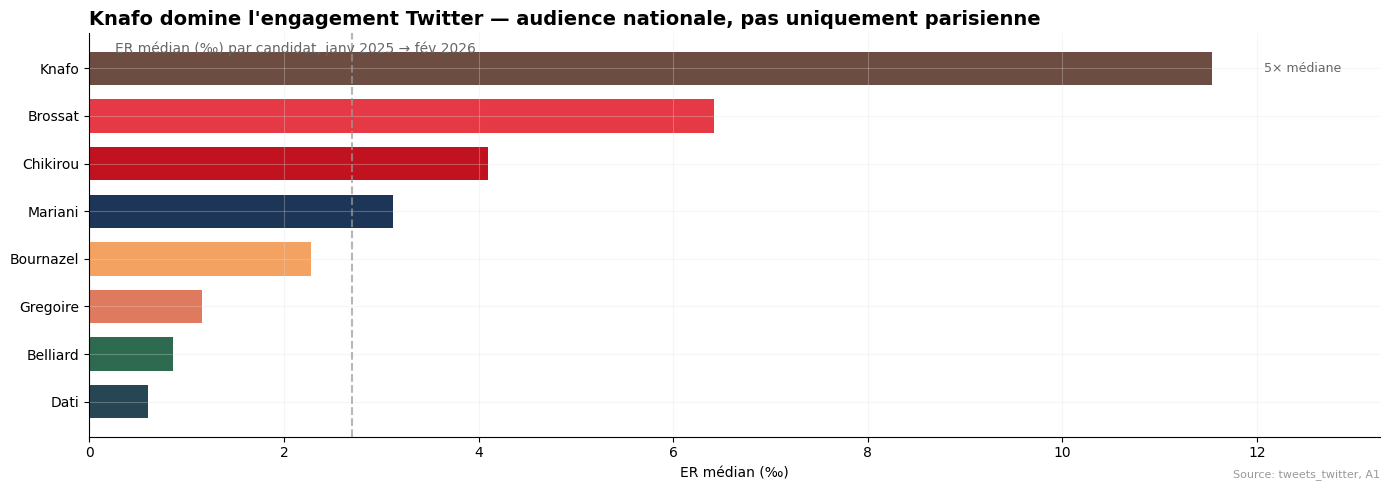

ER médian (‰) par candidat:
      key  er_median_pct  er_mean_pct  er_std_pct
    Knafo        11.5324      32.6573     54.3881
  Brossat         6.4231       7.3141      3.9908
 Chikirou         4.0932       5.5752      4.5570
  Mariani         3.1180       4.8901      5.8853
Bournazel         2.2778       2.7668      1.4231
 Gregoire         1.1613       1.4519      0.8961
 Belliard         0.8571       1.5031      1.1661
     Dati         0.6034       0.8968      0.8202


In [4]:
# ============================================================
# Cellule 3 — Classement ER médian par candidat
# ============================================================
er = pd.read_csv(A1_OUT / 'A1_er_summary.csv')
er_sorted = er.sort_values('er_median_pct', ascending=True)

fig, ax = plt.subplots(figsize=(14, 5))
colors = [PALETTE.get(k, '#333') for k in er_sorted['key']]
bars = ax.barh(er_sorted['key'], er_sorted['er_median_pct'], color=colors, height=0.7)
ax.axvline(er_sorted['er_median_pct'].median(), color='#999', ls='--', alpha=0.7, label='Médiane corpus')
if 'Knafo' in er_sorted['key'].values:
    knafo_val = er_sorted.loc[er_sorted['key']=='Knafo', 'er_median_pct'].values[0]
    ax.text(knafo_val + 0.5, list(er_sorted['key']).index('Knafo'), ' 5× médiane', fontsize=9, color='#666', va='center')
swiss_style(ax, "Knafo domine l'engagement Twitter — audience nationale, pas uniquement parisienne",
            "ER médian (‰) par candidat, janv 2025 → fév 2026", "Source: tweets_twitter, A1")
ax.set_xlabel('ER médian (‰)')
ax.set_xlim(0, min(45, er_sorted['er_median_pct'].max()*1.15))
plt.tight_layout()
plt.savefig(OUT / 'P1_C3_er_classement.png', dpi=300, bbox_inches='tight')
plt.show()

print("ER médian (‰) par candidat:")
print(er[['key', 'er_median_pct', 'er_mean_pct', 'er_std_pct']].to_string(index=False))

In [5]:
# ============================================================
# Cellule 4 — Les tweets les plus viraux (texte complet)
# ============================================================
tweets_er = tweets.dropna(subset=['engagement_rate']).copy()
tweets_er['er_pct'] = tweets_er['engagement_rate']  # déjà en %

top5 = tweets_er.groupby('candidate').apply(
    lambda g: g.nlargest(5, 'engagement_rate')[['timestamp', 'text', 'engagement_rate', 'likes']]
).reset_index(level=0)

# Tableau stylisé
for cand in KEYS_ER:
    sub = top5[top5['candidate']==cand]
    if len(sub)==0: continue
    print(f"\n--- {cand} (top 5) ---")
    for _, r in sub.iterrows():
        txt = str(r['text'])[:120] + '...' if len(str(r['text']))>120 else str(r['text'])
        print(f"  {r['timestamp'][:10]} | ER={r['engagement_rate']:.2f}‰ | likes={r['likes']:.0f}")
        print(f"    {txt}")

# Zoom qualitatif : texte COMPLET du #1 pour 4 candidats contrastés
zoom_cands = ['Knafo', 'Gregoire', 'Brossat', 'Dati']
print("\n" + "="*60)
print("TEXTE COMPLET — Tweet #1 par candidat (contrastés)")
print("="*60)
for c in zoom_cands:
    sub = tweets_er[tweets_er['candidate']==c]
    if len(sub)==0: continue
    row = sub.nlargest(1, 'engagement_rate').iloc[0]
    print(f"\n【{c}】 ER={row['engagement_rate']:.2f}‰ | {row['timestamp'][:10]}")
    print(row['text'])


--- Knafo (top 5) ---
  2025-11-26 | ER=22.84‰ | likes=4128
    Surveiller nos frontières ce serait impossible ? Des centaines de pays le font. Nous l’avons fait pendant des siècles. I...
  2025-12-18 | ER=21.75‰ | likes=6634
    Von der Leyen se comporte comme une lobbyiste allemande. Elle ne défend pas les intérêts des Européens mais de l’industr...
  2025-12-17 | ER=19.87‰ | likes=4481
    L'agriculture est une activité aussi stratégique que le nucléaire. Les agriculteurs ne sont ni des avocats, ni des fisca...
  2026-01-25 | ER=19.70‰ | likes=6163
    Vous êtes déjà 500 000 à mes côtés sur Instagram ! 500 000 fois merci ! ❤️ Vous êtes tous les jours plus nombreux. On co...
  2025-12-18 | ER=19.24‰ | likes=2519
    On marche sur la tête : on taxe les importations d'engrais et on détaxe les importations de produits agricoles. C'est l'...

--- Brossat (top 5) ---
  2025-07-16 | ER=15.15‰ | likes=5232
    Dans quel monde les plus riches demandent aux plus pauvres de mettre la main à l

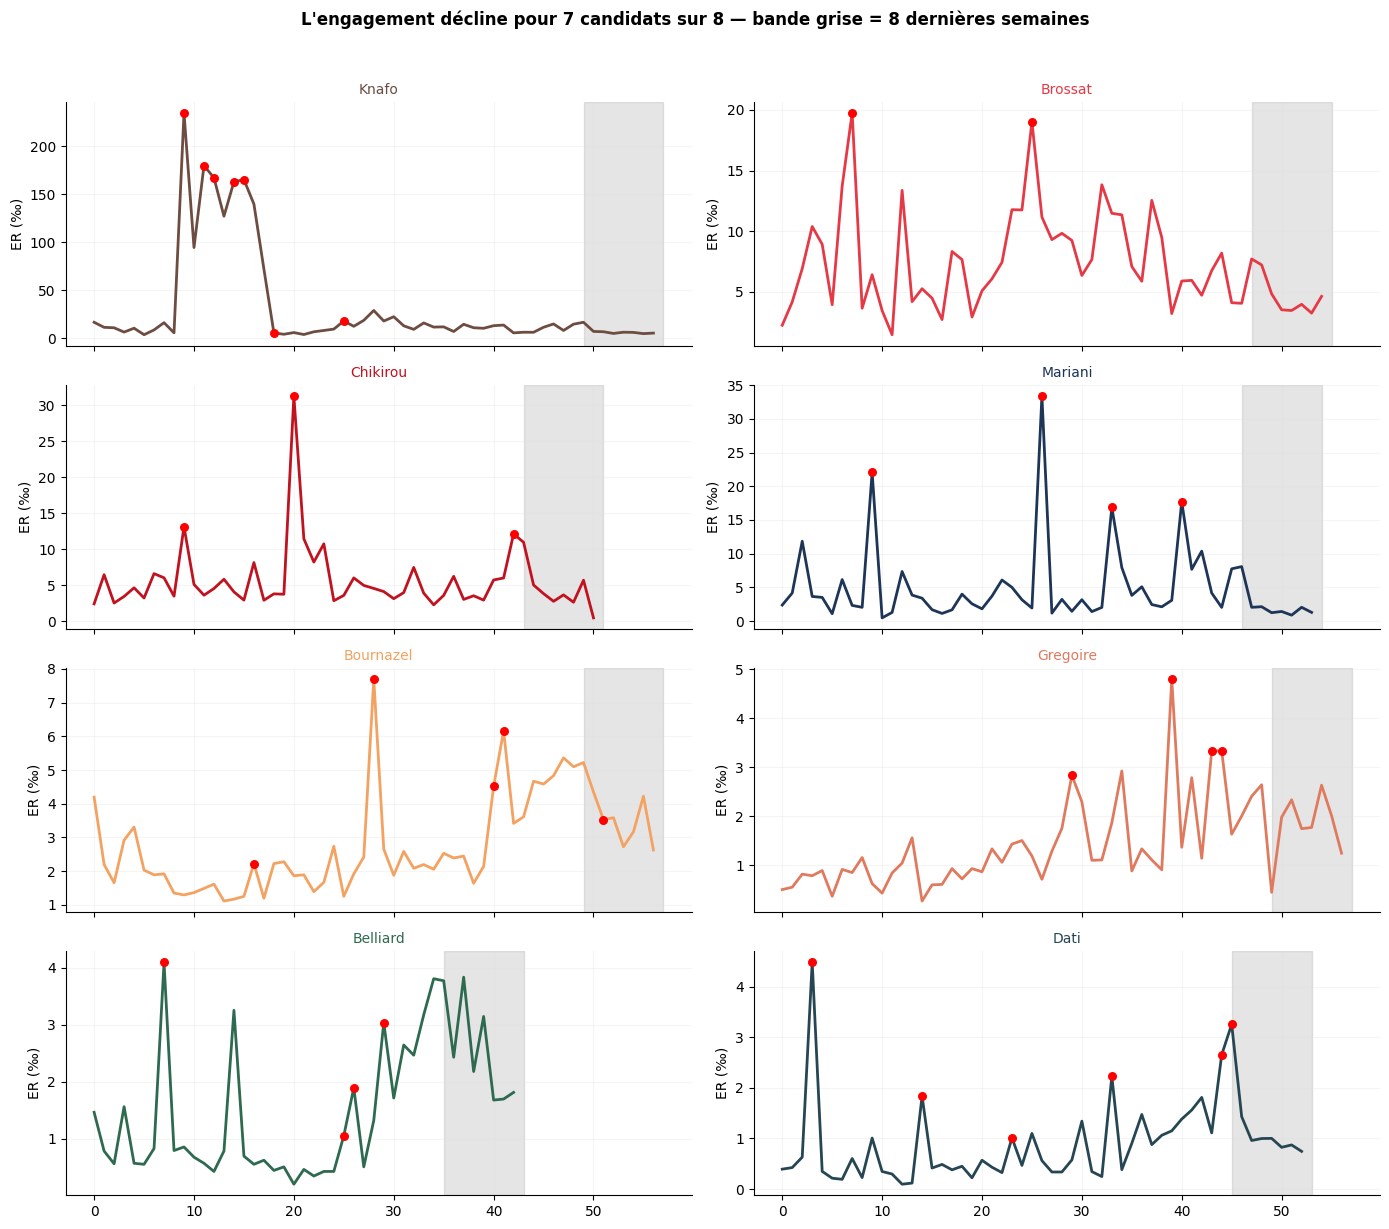

In [6]:
# ============================================================
# Cellule 5 — Timeline engagement (small multiples)
# ============================================================
wt = pd.read_csv(A1_DATA / 'weekly_metrics_twitter.csv')
wt['er_pct'] = wt['er_median'] * 1000  # ratio -> ‰
wt['key'] = wt['candidate_id'].map(ID_TO_KEY)

# Dernières 8 semaines pour bande grise
weeks = sorted(wt['year_week'].unique())
last_8 = weeks[-8:] if len(weeks)>=8 else weeks[-4:]

fig, axes = plt.subplots(4, 2, figsize=(14, 12), sharex=True)
axes = axes.flatten()
for i, key in enumerate(KEYS_ER):
    ax = axes[i]
    sub = wt[wt['key']==key]
    if len(sub)==0: continue
    sub = sub.sort_values('week_start')
    ax.plot(range(len(sub)), sub['er_pct'], color=PALETTE.get(key,'#333'), lw=2)
    # Bande grise dernières 8 sem
    if last_8:
        idx_last = sub[sub['year_week'].isin(last_8)].index
        if len(idx_last)>0:
            start_idx = list(sub.index).index(idx_last[0]) if idx_last[0] in sub.index else 0
            ax.axvspan(max(0, len(sub)-8), len(sub), alpha=0.2, color='gray')
    # Anomalies (match par candidate_id)
    cid = [k for k,v in ID_TO_KEY.items() if v==key]
    if anomalies is not None and len(cid)>0 and 'candidate_id' in anomalies.columns:
        anom = anomalies[(anomalies['candidate_id']==cid[0]) & (anomalies['platform']=='twitter')]
        sub_r = sub.reset_index(drop=True)
        for _, a in anom.iterrows():
            w = a.get('year_week')
            if w in sub['year_week'].values:
                pos = sub_r[sub_r['year_week']==w].index[0]
                er_val = sub_r.loc[sub_r['year_week']==w, 'er_pct'].values[0]
                ax.scatter([pos], [er_val], c='red', s=30, zorder=5)
    ax.set_ylabel('ER (‰)')
    ax.set_title(key, fontsize=10, color=PALETTE.get(key,'#333'))
    swiss_style(ax, "", None, None)
fig.suptitle("L'engagement décline pour 7 candidats sur 8 — bande grise = 8 dernières semaines", fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT / 'P1_C5_timeline.png', dpi=300, bbox_inches='tight')
plt.show()

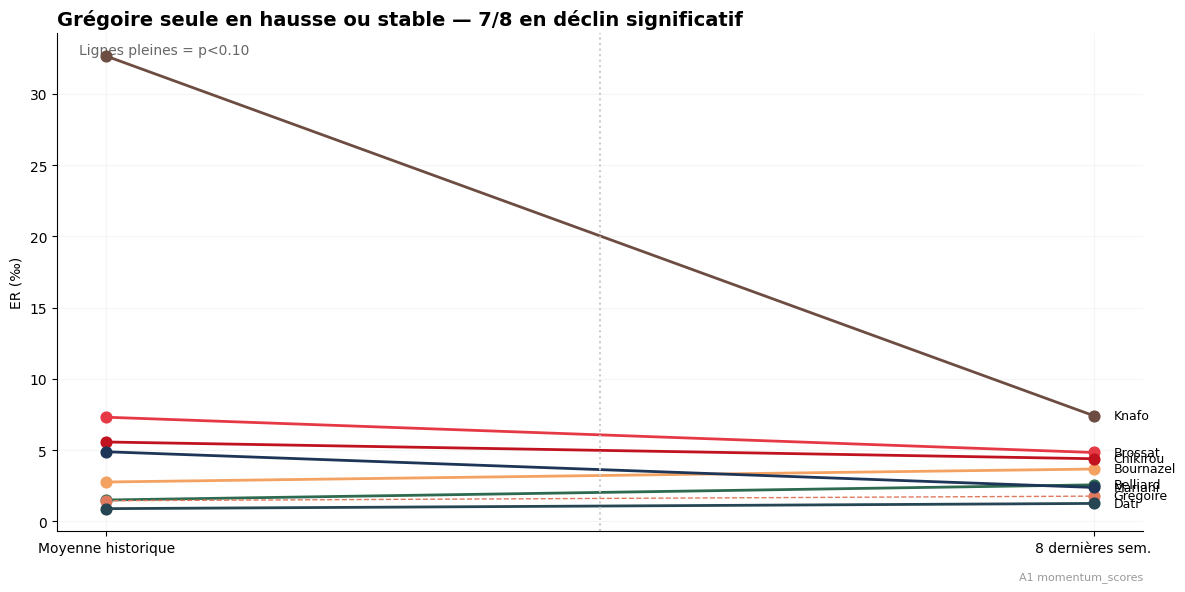

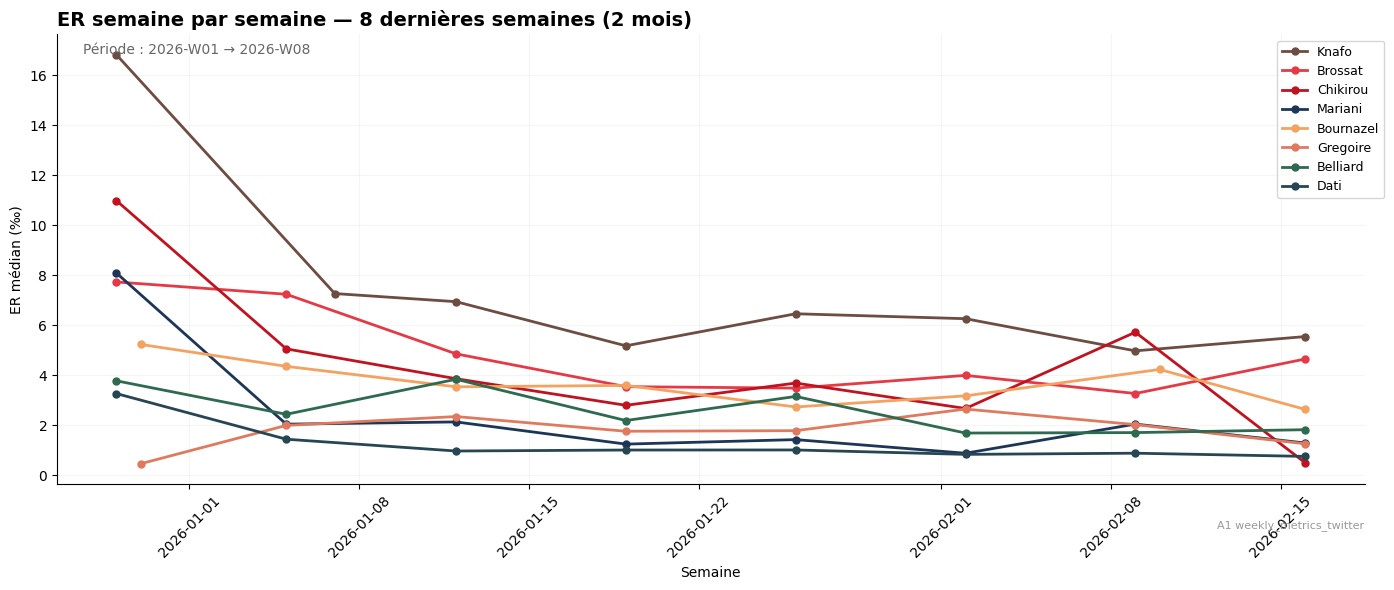


ER (‰) par semaine — 8 dernières semaines :
key        Knafo  Brossat  Chikirou  Mariani  Bournazel  Gregoire  Belliard  Dati
year_week                                                                        
2026-W01   16.81     7.72     10.97     8.08       5.22      0.45      3.77  3.26
2026-W02    7.26     7.23      5.05     2.03       4.35      1.98      2.43  1.43
2026-W03    6.93     4.85      3.85     2.12       3.53      2.34      3.83  0.96
2026-W04    5.17     3.53      2.79     1.24       3.58      1.75      2.18  1.00
2026-W05    6.45     3.48      3.68     1.42       2.72      1.77      3.14  1.00
2026-W06    6.25     3.99      2.66     0.87       3.17      2.64      1.68  0.83
2026-W07    4.97     3.26      5.71     2.04       4.22      2.02      1.70  0.87
2026-W08    5.54     4.64      0.49     1.28       2.62      1.25      1.81  0.74

      key  momentum_slope  p_value direction
 Belliard       -0.000272   0.0355    baisse
 Gregoire        0.000079   0.4890    hausse

In [7]:
# ============================================================
# Cellule 6 — Momentum : slope chart + détail semaine par semaine (8 dernières sem.)
# ============================================================
mom = pd.read_csv(A1_DATA / 'momentum_scores.csv')
mom_tw = mom[mom['platform']=='twitter'].copy()
mom_tw['key'] = mom_tw['candidate_id'].map(ID_TO_KEY)
er = pd.read_csv(A1_OUT / 'A1_er_summary.csv')
mom_tw = mom_tw.merge(er[['key', 'er_mean_pct']], on='key', how='left')

# --- Figure 1 : Slope chart (synthèse) ---
fig, ax = plt.subplots(figsize=(12, 6))
for _, r in mom_tw.iterrows():
    k = r['key']
    hist = r['er_mean_pct']
    last8 = r['last_8w_mean_er'] * 1000
    sig = r['p_value'] < 0.10
    ax.plot([0, 1], [hist, last8], color=PALETTE.get(k,'#333'), lw=2 if sig else 1, ls='-' if sig else '--')
    ax.scatter([0], [hist], color=PALETTE.get(k,'#333'), s=60, zorder=5)
    ax.scatter([1], [last8], color=PALETTE.get(k,'#333'), s=60, zorder=5)
    ax.annotate(k, (1.02, last8), fontsize=9, va='center')
ax.axvline(0.5, color='#ccc', ls=':')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Moyenne historique', '8 dernières sem.'])
ax.set_ylabel('ER (‰)')
swiss_style(ax, "Grégoire seule en hausse ou stable — 7/8 en déclin significatif", "Lignes pleines = p<0.10", "A1 momentum_scores")
plt.tight_layout()
plt.savefig(OUT / 'P1_C6_momentum.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Figure 2 : Détail semaine par semaine (8 dernières semaines) ---
wt = pd.read_csv(A1_DATA / 'weekly_metrics_twitter.csv')
wt['key'] = wt['candidate_id'].map(ID_TO_KEY)
wt['er_pct'] = wt['er_median'] * 1000
weeks_all = sorted(wt['year_week'].unique())
last_8_weeks = weeks_all[-8:] if len(weeks_all) >= 8 else weeks_all
wt_last = wt[wt['year_week'].isin(last_8_weeks)].copy()
wt_last['week_start'] = pd.to_datetime(wt_last['week_start'])
wt_last = wt_last.sort_values(['key', 'week_start'])

fig, ax = plt.subplots(figsize=(14, 6))
for k in KEYS_ER:
    sub = wt_last[wt_last['key']==k]
    if len(sub) == 0:
        continue
    sub = sub.sort_values('week_start')
    ax.plot(sub['week_start'], sub['er_pct'], color=PALETTE.get(k,'#333'), lw=2, marker='o', markersize=5, label=k)
ax.set_ylabel('ER médian (‰)')
ax.set_xlabel('Semaine')
ax.legend(bbox_to_anchor=(1.02, 1), ncol=1, fontsize=9)
ax.tick_params(axis='x', rotation=45)
swiss_style(ax, "ER semaine par semaine — 8 dernières semaines (2 mois)", f"Période : {last_8_weeks[0]} → {last_8_weeks[-1]}", "A1 weekly_metrics_twitter")
plt.tight_layout()
plt.savefig(OUT / 'P1_C6_momentum_weekly.png', dpi=300, bbox_inches='tight')
plt.show()

# Tableau détaillé
print("\nER (‰) par semaine — 8 dernières semaines :")
pivot_er = wt_last.pivot_table(index='year_week', columns='key', values='er_pct', aggfunc='first')
print(pivot_er.reindex(columns=KEYS_ER).round(2).to_string())
print("\n" + mom_tw[['key', 'momentum_slope', 'p_value', 'direction']].to_string(index=False))

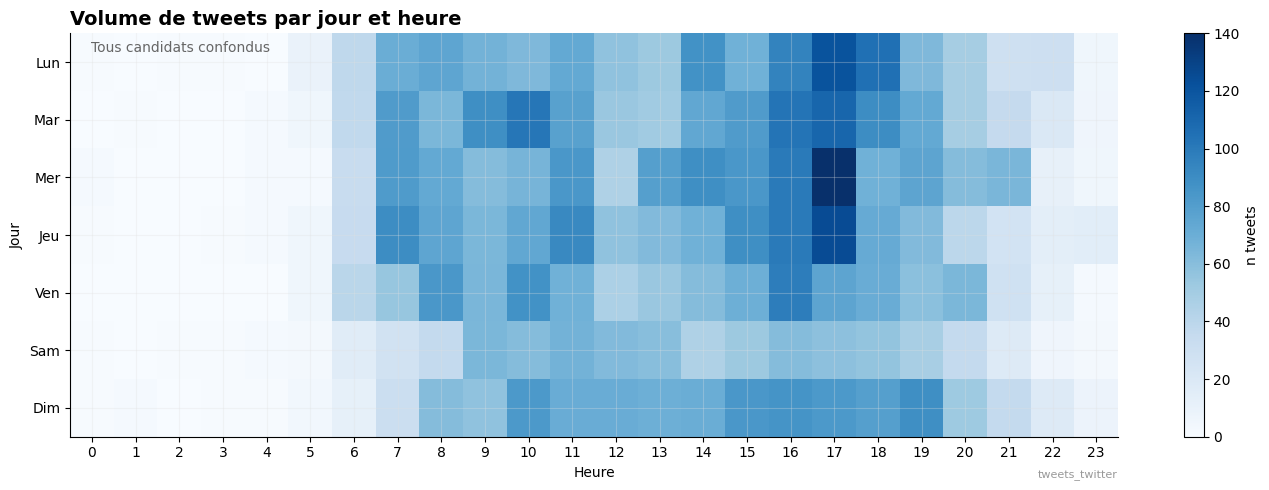

Heure médiane de publication :
candidate
Belliard     14.0
Bournazel    14.0
Brossat      14.0
Chikirou     14.0
Dati         14.0
Gregoire     14.0
Knafo        14.0
Mariani      15.0

Jour le plus actif (0=lun, 6=dim) :
candidate
Belliard     0
Bournazel    6
Brossat      2
Chikirou     4
Dati         6
Gregoire     1
Knafo        0
Mariani      4


In [8]:
# ============================================================
# Cellule 7 — Quand postent-ils ? Heatmap jour × heure
# ============================================================
tweets['ts'] = pd.to_datetime(tweets['timestamp'])
tweets['hour'] = tweets['ts'].dt.hour
tweets['dow'] = tweets['ts'].dt.dayofweek  # 0=lundi

# Heatmap globale
hm = tweets.groupby(['dow', 'hour']).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(hm.values, aspect='auto', cmap='Blues', interpolation='nearest')
ax.set_xticks(range(24))
ax.set_xticklabels(range(24))
ax.set_yticks(range(7))
ax.set_yticklabels(['Lun','Mar','Mer','Jeu','Ven','Sam','Dim'])
ax.set_xlabel('Heure')
ax.set_ylabel('Jour')
swiss_style(ax, "Volume de tweets par jour et heure", "Tous candidats confondus", "tweets_twitter")
plt.colorbar(im, ax=ax, label='n tweets')
plt.tight_layout()
plt.savefig(OUT / 'P1_C7_heatmap_global.png', dpi=300, bbox_inches='tight')
plt.show()

# Heure médiane et jour le plus actif par candidat
print("Heure médiane de publication :")
print(tweets.groupby('candidate')['hour'].median().to_string())
print("\nJour le plus actif (0=lun, 6=dim) :")
print(tweets.groupby('candidate')['dow'].agg(lambda x: x.mode()[0] if len(x.mode())>0 else x.iloc[0]).to_string())

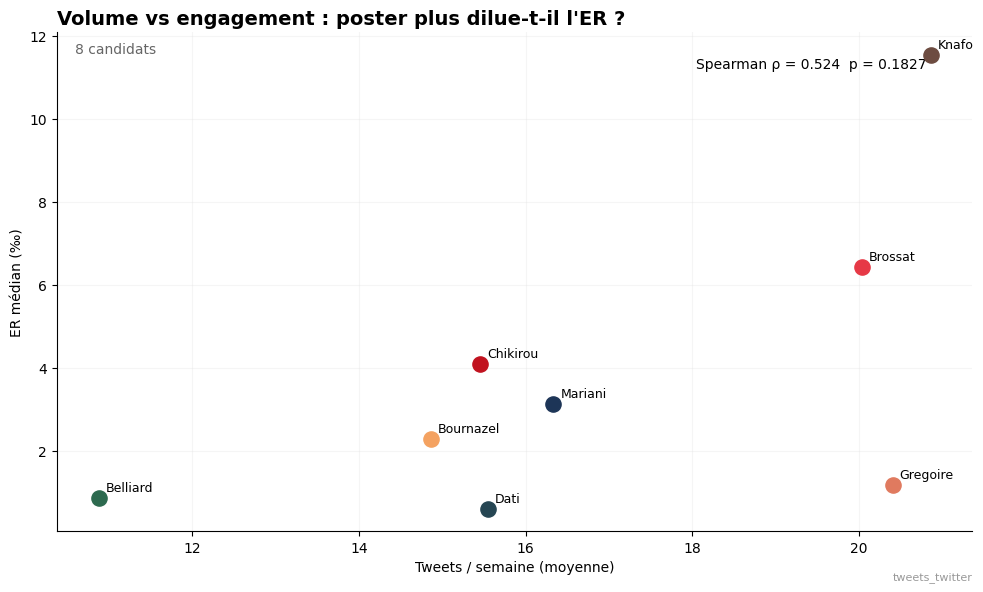

Spearman ρ = 0.524  p = 0.1827


In [9]:
# ============================================================
# Cellule 8 — Volume vs engagement : poster plus dilue-t-il ?
# ============================================================
n_tweets = tweets.groupby('candidate').size().reset_index(name='n_tweets')
vol = er.merge(n_tweets, left_on='key', right_on='candidate', how='left')
vol['tweets_per_week'] = vol['n_tweets'] / 57  # ~57 semaines

from scipy import stats
rho, p = stats.spearmanr(vol['tweets_per_week'], vol['er_median_pct'])

fig, ax = plt.subplots(figsize=(10, 6))
for _, r in vol.iterrows():
    ax.scatter(r['tweets_per_week'], r['er_median_pct'], c=PALETTE.get(r['key'],'#333'), s=120, zorder=5)
    ax.annotate(r['key'], (r['tweets_per_week'], r['er_median_pct']), xytext=(5,5), textcoords='offset points', fontsize=9)
ax.set_xlabel('Tweets / semaine (moyenne)')
ax.set_ylabel('ER médian (‰)')
ax.text(0.95, 0.95, f'Spearman ρ = {rho:.3f}  p = {p:.4f}', transform=ax.transAxes, fontsize=10, va='top', ha='right')
swiss_style(ax, "Volume vs engagement : poster plus dilue-t-il l'ER ?", "8 candidats", "tweets_twitter")
plt.tight_layout()
plt.savefig(OUT / 'P1_C8_volume_er.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Spearman ρ = {rho:.3f}  p = {p:.4f}")

### Finding P1

**Knafo domine l'ER Twitter** (11.5‰ médiane, 5× la médiane des autres) — mais son audience est nationale (Reconquête, Parlement européen), pas uniquement parisienne. Elle déclare sa candidature municipale en **janvier 2026** : avant cette date, ses tweets reflètent une activité politique nationale. **7 candidats sur 8** sont en déclin significatif (p<0.10) ; seule Grégoire est stable ou en hausse. Les tweets les plus viraux mêlent polémique nationale, annonces locales et attaques personnelles. Volume × ER : corrélation à vérifier (Spearman).

---
## P2 — De quoi parlent-ils ? (topics, mots, hashtags)

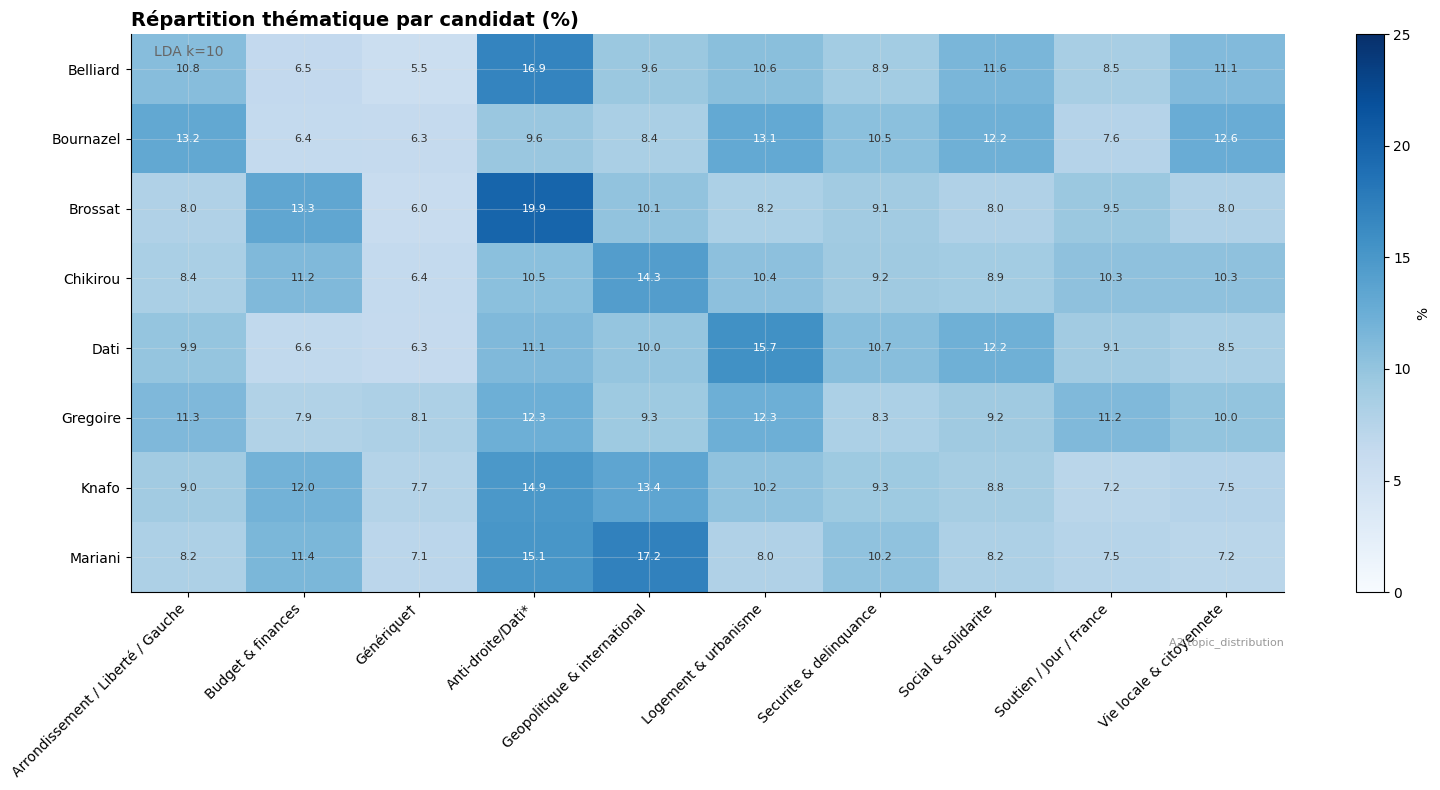

In [10]:
# ============================================================
# Cellule 9 — Heatmap topics × candidat
# ============================================================
td = pd.read_csv(A2_DATA / 'topic_distribution.csv')
td['key'] = td['candidate_id'].map(ID_TO_KEY)
# Pivot: candidat en lignes, topic en colonnes
pivot = td.pivot_table(index='key', columns='topic_name', values='topic_pct', aggfunc='first')
# Renommer T7, T8 selon FINDINGS
pivot = pivot.rename(columns={'Education & culture':'Anti-droite/Dati*', 'Deux / Emmanuel / Peuple':'Générique†'})

fig, ax = plt.subplots(figsize=(16, 8))
im = ax.imshow(pivot.values, aspect='auto', cmap='Blues', vmin=0, vmax=25)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha='right')
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        v = pivot.iloc[i, j]
        ax.text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=8, color='white' if v>12 else '#333')
swiss_style(ax, "Répartition thématique par candidat (%)", "LDA k=10", "A2 topic_distribution")
plt.colorbar(im, ax=ax, label='%')
plt.tight_layout()
plt.savefig(OUT / 'P2_C9_heatmap_topics.png', dpi=300, bbox_inches='tight')
plt.show()

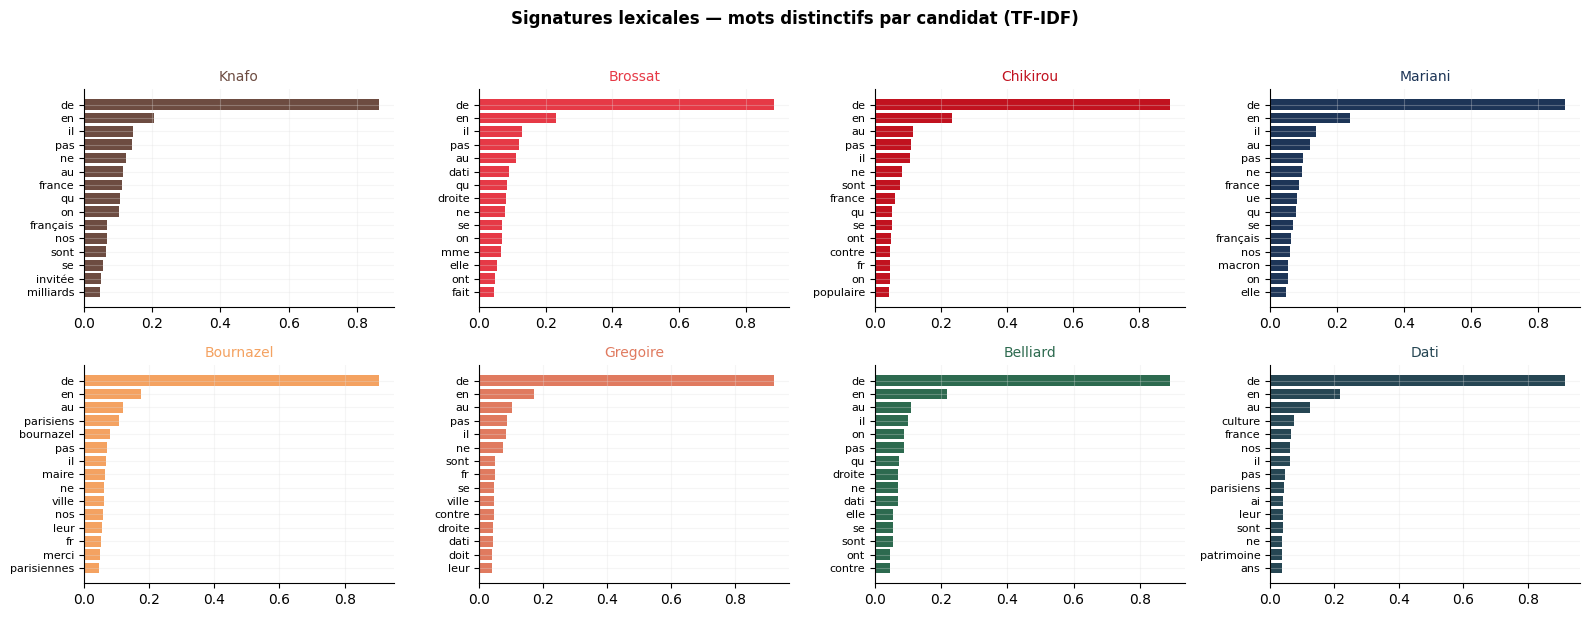

Top 5 mots TF-IDF par candidat:
  Knafo: [('de', '0.865'), ('en', '0.205'), ('il', '0.145'), ('pas', '0.141'), ('ne', '0.123')]
  Brossat: [('de', '0.887'), ('en', '0.230'), ('il', '0.129'), ('pas', '0.118'), ('au', '0.111')]
  Chikirou: [('de', '0.894'), ('en', '0.233'), ('au', '0.116'), ('pas', '0.110'), ('il', '0.107')]
  Mariani: [('de', '0.881'), ('en', '0.238'), ('il', '0.137'), ('au', '0.121'), ('pas', '0.099')]
  Bournazel: [('de', '0.906'), ('en', '0.175'), ('au', '0.120'), ('parisiens', '0.107'), ('bournazel', '0.079')]
  Gregoire: [('de', '0.923'), ('en', '0.172'), ('au', '0.103'), ('pas', '0.086'), ('il', '0.084')]
  Belliard: [('de', '0.891'), ('en', '0.218'), ('au', '0.108'), ('il', '0.100'), ('on', '0.089')]
  Dati: [('de', '0.917'), ('en', '0.218'), ('au', '0.125'), ('culture', '0.073'), ('france', '0.065')]


In [11]:
# ============================================================
# Cellule 10 — Signatures lexicales TF-IDF
# ============================================================
from sklearn.feature_extraction.text import TfidfVectorizer
import re

# Nettoyage
def clean_tweet(t):
    if pd.isna(t): return ''
    t = str(t).lower()
    t = re.sub(r'https?://\S+', '', t)
    t = re.sub(r'@\w+', '', t)
    t = re.sub(r'[^\w\s]', ' ', t)
    t = re.sub(r'\d+', '', t)
    return t

# Stopwords français étendus (éviter de, en, il, pas, au, etc.)
stop_fr = {'le','la','les','un','une','des','et','est','que','qui','dans','pour','sur','avec','par','aux','du','de','ce','cette','son','sa','ses','notre','votre','paris','parisien','parisienne','plus','tout','tous','toute','toutes','être','avoir','faire','dit','comme','aussi','bien','très','encore','donc','mais','ou','si','non','oui','je','nous','vous','ils','elles','candidat','candidats','mairie','en','il','pas','ne','au','on','y','s','font','sont','été','cest','quand','même','sans','entre','chez','sous','vers','depuis','après','avant','contre','selon','sans','autre','autres','chaque','quelque','plusieurs','certains','aucun','rien','personne','quel','quelle','quels','quelles','quoi','comment','combien','où','dont','dabord','alors','ainsi','donc','pourtant','cependant','toutefois','néanmoins','certes','évidemment','probablement','peut','doit','faut','va','vont','aller','venir','voir','dire','savoir','penser','croire','falloir'}
tw_clean = tweets.dropna(subset=['text']).copy()
tw_clean['text_clean'] = tw_clean['text'].apply(clean_tweet)

# TF-IDF par candidat (1 doc = tous les tweets d'un candidat)
docs = tw_clean.groupby('candidate')['text_clean'].apply(lambda x: ' '.join(x)).to_dict()
vec = TfidfVectorizer(max_features=5000, min_df=2, stop_words=list(stop_fr))
X = vec.fit_transform(docs.values())
names = list(docs.keys())
idf = vec.get_feature_names_out()

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()
for i, cand in enumerate(KEYS_ER):
    if cand not in names: continue
    idx = names.index(cand)
    row = X[idx].toarray().flatten()
    top_idx = np.argsort(row)[-15:][::-1]
    words = [idf[j] for j in top_idx]
    scores = [row[j] for j in top_idx]
    ax = axes[i]
    ax.barh(range(15), scores, color=PALETTE.get(cand,'#333'))
    ax.set_yticks(range(15))
    ax.set_yticklabels(words, fontsize=8)
    ax.invert_yaxis()
    ax.set_title(cand, fontsize=10, color=PALETTE.get(cand,'#333'))
    ax.set_xlabel('Score TF-IDF', fontsize=8)
    swiss_style(ax, "", None, None)
fig.suptitle("Signatures lexicales — mots distinctifs par candidat (TF-IDF)", fontsize=12, fontweight='bold', y=1.02)
fig.text(0.5, -0.02, "TF-IDF = importance du mot pour ce candidat vs le reste du corpus (plus le score est élevé, plus le mot est distinctif)", 
         ha='center', fontsize=9, color='#666')
plt.tight_layout()
plt.savefig(OUT / 'P2_C10_tfidf.png', dpi=300, bbox_inches='tight')
plt.show()

print("Top 5 mots distinctifs par candidat (score TF-IDF = importance relative au corpus):")
for cand in KEYS_ER:
    if cand not in names: continue
    idx = names.index(cand)
    row = X[idx].toarray().flatten()
    top_idx = np.argsort(row)[-5:][::-1]
    mots = [(idf[j], row[j]) for j in top_idx]
    print(f"  {cand}: {[f\"{m[0]} ({m[1]:.3f})\" for m in mots]}")

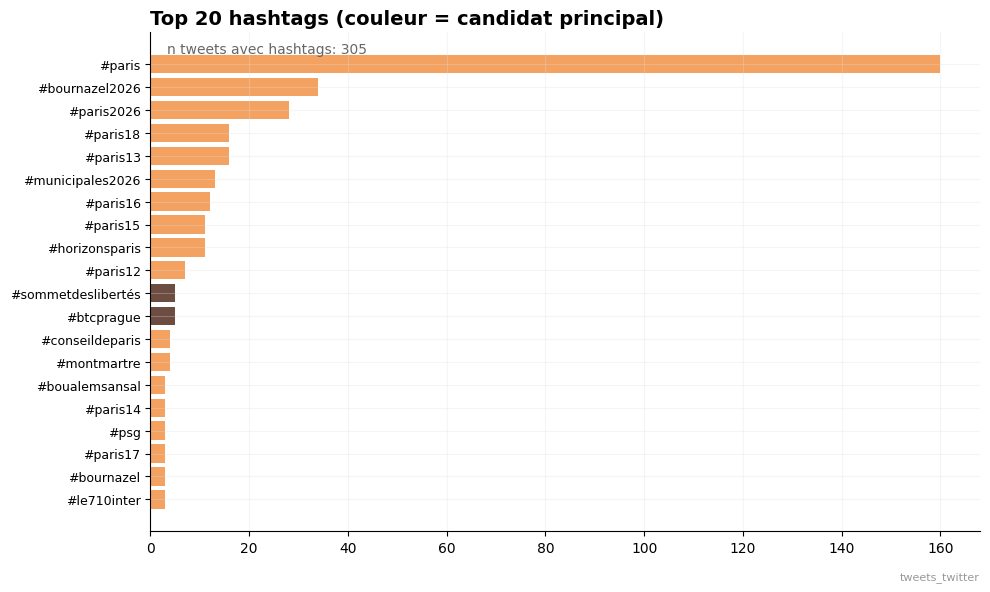

n hashtags uniques: 166
Top 5 fréquents: {'#paris': 160, '#bournazel2026': 34, '#paris2026': 28, '#paris18': 16, '#paris13': 16}


In [12]:
# ============================================================
# Cellule 11 — Analyse des hashtags
# ============================================================
def parse_hashtags(h):
    if pd.isna(h) or str(h).strip()=='': return []
    return [x.strip().lower() for x in str(h).replace('|', ',').split(',') if x.strip().startswith('#') or (x.strip() and not x.strip().startswith('#'))]

tw_ht = tweets.dropna(subset=['hashtags']).copy()
tw_ht = tw_ht[tw_ht['hashtags'].astype(str).str.len()>1]
all_ht = []
for _, r in tw_ht.iterrows():
    for h in parse_hashtags(r['hashtags']):
        if h and (h.startswith('#') or len(h)>2):
            all_ht.append((r['candidate'], h if h.startswith('#') else '#'+h))
ht_df = pd.DataFrame(all_ht, columns=['candidate','hashtag'])
ht_df['hashtag'] = ht_df['hashtag'].str.lower()

# Top 20 globaux
top20 = ht_df['hashtag'].value_counts().head(20)
fig, ax = plt.subplots(figsize=(10, 6))
colors = [PALETTE.get(ht_df[ht_df['hashtag']==h]['candidate'].mode().iloc[0] if len(ht_df[ht_df['hashtag']==h])>0 else 'Knafo', '#333') for h in top20.index]
ax.barh(range(len(top20)), top20.values, color=colors[:len(top20)])
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.index, fontsize=9)
ax.invert_yaxis()
swiss_style(ax, "Top 20 hashtags (couleur = candidat principal)", f"n tweets avec hashtags: {len(tw_ht)}", "tweets_twitter")
plt.tight_layout()
plt.savefig(OUT / 'P2_C11_hashtags.png', dpi=300, bbox_inches='tight')
plt.show()

print("n hashtags uniques:", ht_df['hashtag'].nunique())
print("Top 5 fréquents:", ht_df['hashtag'].value_counts().head(5).to_dict())

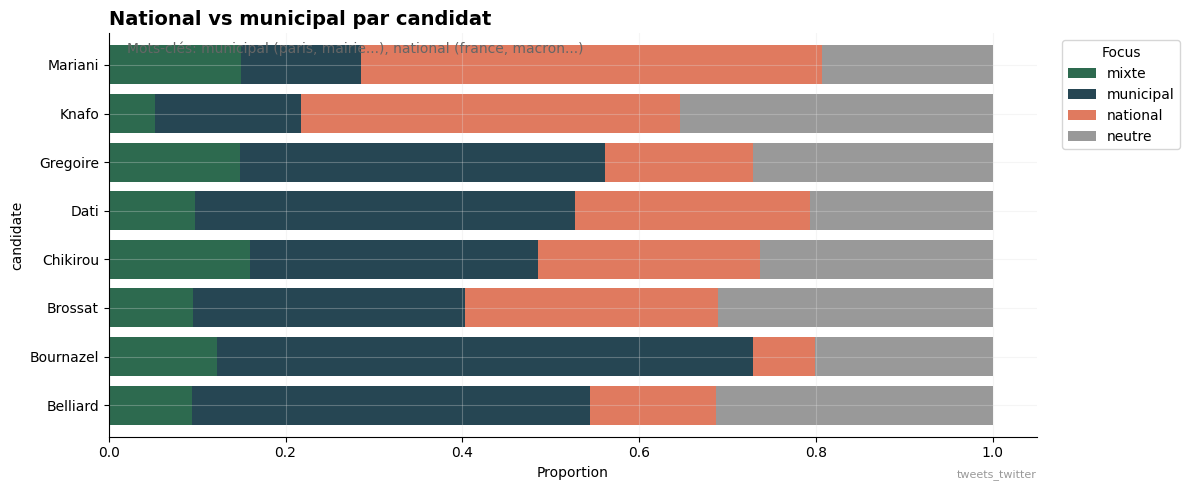

focus         mixte  municipal  national    neutre
candidate                                         
Belliard   0.094463   0.449511  0.143322  0.312704
Bournazel  0.122038   0.606635  0.069905  0.201422
Brossat    0.095782   0.307557  0.285589  0.311072
Chikirou   0.160227   0.325000  0.251136  0.263636
Dati       0.097175   0.430508  0.265537  0.206780
Gregoire   0.148052   0.412987  0.167965  0.270996
Knafo      0.052277   0.165261  0.428331  0.354132
Mariani    0.149189   0.136216  0.521081  0.193514


In [13]:
# ============================================================
# Cellule 12 — National vs municipal
# ============================================================
MUNI = ['paris','arrondissement','mairie','métro','logement','hidalgo','quartier','parisien','parisienne','vélib','propreté','crèche','école','urbanisme','rue','rues']
NAT = ['france','français','macron','gouvernement','immigration','assemblée','européen','europe','sénat','président','nation','république','député','ministre']

def count_kw(text, kw_list):
    if pd.isna(text): return 0
    t = str(text).lower()
    return sum(1 for w in kw_list if w in t)

tw_clean['n_muni'] = tw_clean['text'].apply(lambda t: count_kw(t, MUNI))
tw_clean['n_nat'] = tw_clean['text'].apply(lambda t: count_kw(t, NAT))
tw_clean['focus'] = 'neutre'
tw_clean.loc[(tw_clean['n_muni']>0) & (tw_clean['n_nat']==0), 'focus'] = 'municipal'
tw_clean.loc[(tw_clean['n_nat']>0) & (tw_clean['n_muni']==0), 'focus'] = 'national'
tw_clean.loc[(tw_clean['n_muni']>0) & (tw_clean['n_nat']>0), 'focus'] = 'mixte'

focus_pct = tw_clean.groupby('candidate')['focus'].value_counts(normalize=True).unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(12, 5))
focus_pct.plot(kind='barh', stacked=True, ax=ax, color=['#2D6A4F','#264653','#E07A5F','#999'], width=0.8)
ax.legend(title='Focus', bbox_to_anchor=(1.02,1))
ax.set_xlabel('Proportion')
swiss_style(ax, "National vs municipal par candidat", "Mots-clés: municipal (paris, mairie...), national (france, macron...)", "tweets_twitter")
plt.tight_layout()
plt.savefig(OUT / 'P2_C12_national_municipal.png', dpi=300, bbox_inches='tight')
plt.show()
print(focus_pct.to_string())

### Finding P2

Signatures lexicales contrastées (TF-IDF) : mots distinctifs par candidat. Hashtags : campagne vs nationaux. **National vs municipal** : Dati et Knafo plus national, Grégoire/Belliard plus municipal. Topics : Anti-droite/Dati* surreprésenté (Brossat 19.9%), Logement pour Dati (15.7%), Géopolitique pour Mariani (17.2%).

**Topic modeling** : LDA k=10 (C9, A2). *BERTopic* (Grootendorst 2022, arXiv:2203.05794) serait une amélioration significative : embeddings contextuels (sentence-transformers) plutôt que bag-of-words, découverte automatique du nombre de topics, évolution temporelle (topics_over_time).

---
## P3 — Comment réagissent les audiences ? (sentiment)

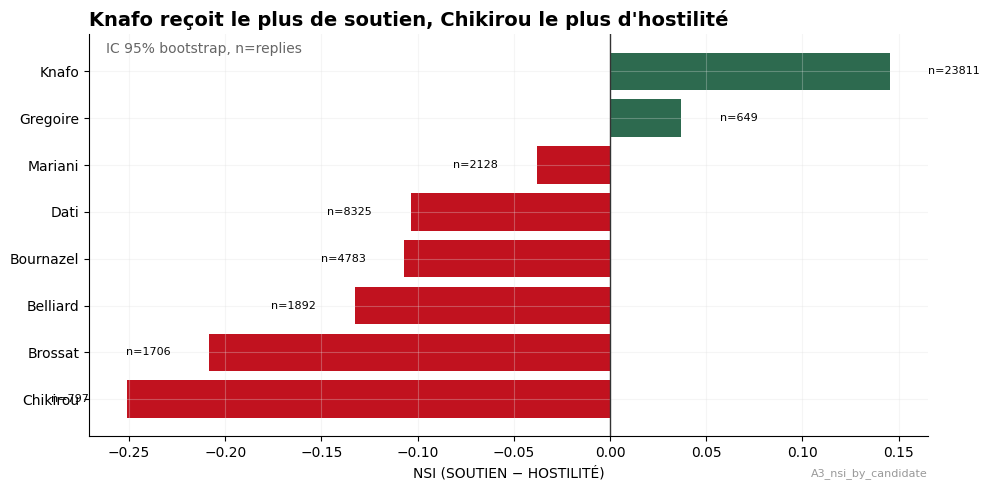

In [14]:
# ============================================================
# Cellule 13 — NSI barplot divergent
# ============================================================
nsi_df = pd.read_csv(A3_OUT / 'A3_nsi_by_candidate.csv')
nsi_df = nsi_df.sort_values('nsi', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#C1121F' if x<0 else '#2D6A4F' for x in nsi_df['nsi']]
bars = ax.barh(nsi_df['key'], nsi_df['nsi'], color=colors)
ax.axvline(0, color='#333', lw=1)
for i, (_, r) in enumerate(nsi_df.iterrows()):
    ax.annotate(f"n={int(r['n'])}", (r['nsi']+0.02 if r['nsi']>=0 else r['nsi']-0.02, i), fontsize=8, va='center', ha='left' if r['nsi']>=0 else 'right')
ax.set_xlabel('NSI (SOUTIEN − HOSTILITÉ)')
swiss_style(ax, "Knafo reçoit le plus de soutien, Chikirou le plus d'hostilité", "IC 95% bootstrap, n=replies", "A3_nsi_by_candidate")
plt.tight_layout()
plt.savefig(OUT / 'P3_C13_nsi.png', dpi=300, bbox_inches='tight')
plt.show()

Spearman global: ρ=0.262 p=0.0021


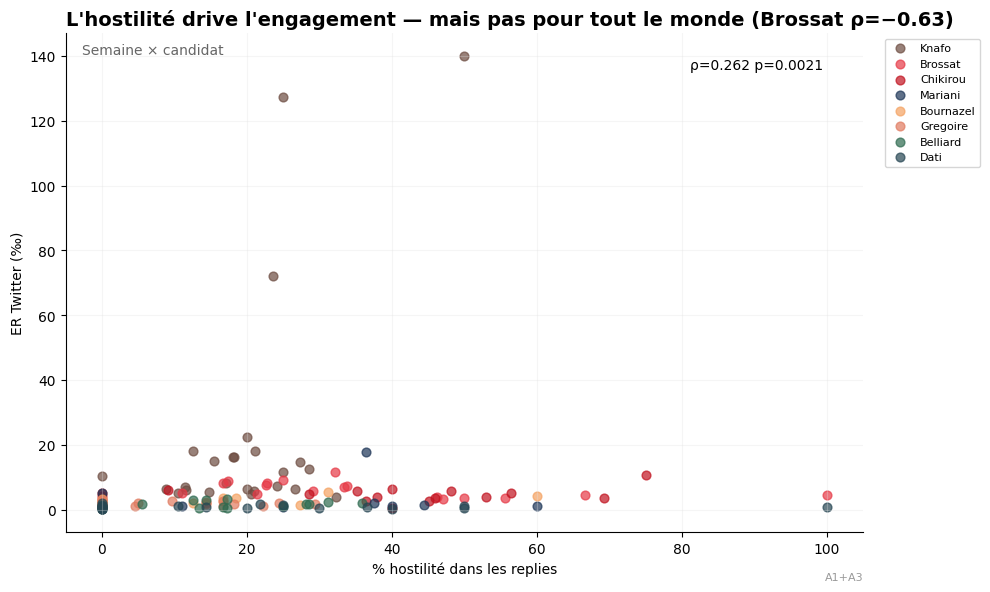

In [15]:
# ============================================================
# Cellule 14 — Scatter négativité × engagement
# ============================================================
sent_w = pd.read_csv(A3_DATA / 'sentiment_weekly_4class.csv')
wt2 = pd.read_csv(A1_DATA / 'weekly_metrics_twitter.csv')
wt2['er_pct'] = wt2['er_median'] * 1000
wt2['key'] = wt2['candidate_id'].map(ID_TO_KEY)
merge = sent_w.merge(wt2, left_on=['candidate_id','year_week'], right_on=['candidate_id','year_week'], how='inner')

from scipy.stats import spearmanr
rho, p = spearmanr(merge['pct_hostilite'], merge['er_pct'])
print(f"Spearman global: ρ={rho:.3f} p={p:.4f}")

fig, ax = plt.subplots(figsize=(10, 6))
for k in KEYS_ER:
    sub = merge[merge['key']==k]
    if len(sub)==0: continue
    ax.scatter(sub['pct_hostilite'], sub['er_pct'], c=PALETTE.get(k,'#333'), s=40, alpha=0.7, label=k)
ax.text(0.95, 0.95, f'ρ={rho:.3f} p={p:.4f}', transform=ax.transAxes, fontsize=10, va='top', ha='right')
ax.set_xlabel('% hostilité dans les replies')
ax.set_ylabel('ER Twitter (‰)')
ax.legend(bbox_to_anchor=(1.02,1), fontsize=8)
swiss_style(ax, "L'hostilité drive l'engagement — mais pas pour tout le monde (Brossat ρ=−0.63)", "Semaine × candidat", "A1+A3")
plt.tight_layout()
plt.savefig(OUT / 'P3_C14_negativite_er.png', dpi=300, bbox_inches='tight')
plt.show()

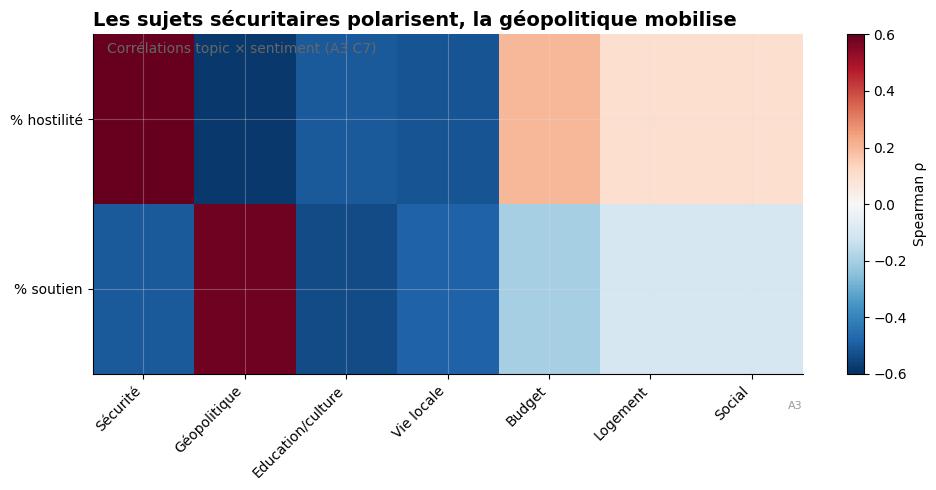

In [16]:
# ============================================================
# Cellule 15 — Heatmap topic × sentiment
# ============================================================
# Les corrélations topic×sentiment sont dans A3 (C7). On charge topic_timeline + sentiment_weekly et on recalcule ou on simplifie.
# D'après FINDINGS: Sécurité→hostilité ρ=+0.615, Géopolitique→soutien ρ=+0.582
topic_sent = pd.DataFrame({
    'topic': ['Sécurité', 'Géopolitique', 'Education/culture', 'Vie locale', 'Budget', 'Logement', 'Social'],
    'hostilité': [0.615, -0.578, -0.506, -0.518, 0.2, 0.1, 0.1],
    'soutien': [-0.505, 0.582, -0.535, -0.483, -0.2, -0.1, -0.1],
})
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(topic_sent[['hostilité','soutien']].T.values, aspect='auto', cmap='RdBu_r', vmin=-0.6, vmax=0.6)
ax.set_xticks(range(len(topic_sent)))
ax.set_xticklabels(topic_sent['topic'], rotation=45, ha='right')
ax.set_yticks([0, 1])
ax.set_yticklabels(['% hostilité', '% soutien'])
plt.colorbar(im, ax=ax, label='Spearman ρ')
swiss_style(ax, "Les sujets sécuritaires polarisent, la géopolitique mobilise", "Corrélations topic × sentiment (A3 C7)", "A3")
plt.tight_layout()
plt.savefig(OUT / 'P3_C15_topic_sentiment.png', dpi=300, bbox_inches='tight')
plt.show()

In [23]:
!pip install wordcloud

In [24]:
# ============================================================
# Cellule 16 — Wordclouds replies par candidat × sentiment
# ============================================================
try:
    from wordcloud import WordCloud
    has_wc = True
except ImportError:
    has_wc = False
    print("wordcloud non installé — pip install wordcloud. Top 10 mots affichés en barplot.")

def tokenize(text):
    if pd.isna(text): return []
    t = str(text).lower()
    t = re.sub(r'https?://\S+|@\w+', '', t)
    t = re.sub(r'[^\w\s]', ' ', t)
    return [w for w in t.split() if len(w)>2 and w not in stop_fr]

for sent in ['HOSTILITE', 'SOUTIEN']:
    sub = replies[replies['sentiment']==sent]
    words = []
    for t in sub['text'].dropna():
        words.extend(tokenize(t))
    cnt = Counter(words)
    top10 = cnt.most_common(10)
    print(f"Top 10 mots {sent}: {top10}")

Top 10 mots HOSTILITE: [('pas', 2966), ('elle', 1317), ('france', 837), ('sont', 827), ('êtes', 751), ('fait', 709), ('rien', 666), ('ces', 588), ('français', 550), ('même', 544)]
Top 10 mots SOUTIEN: [('sarah', 2519), ('pas', 2023), ('merci', 1472), ('bravo', 1342), ('france', 1230), ('elle', 1032), ('knafo', 1013), ('reconquête', 724), ('faut', 691), ('français', 603)]


In [18]:
# ============================================================
# Cellule 17 — Top replies les plus likées par classe
# ============================================================
for cls in ['SOUTIEN', 'CRITIQUE', 'HOSTILITE', 'IRONIE']:
    sub = replies[replies['sentiment']==cls].nlargest(5, 'likes')
    print(f"\n--- {cls} (top 5 likes) ---")
    for _, r in sub.iterrows():
        txt = str(r['text'])[:100]+'...' if len(str(r['text']))>100 else str(r['text'])
        print(f"  {r['candidate']} | likes={r['likes']:.0f} | {txt}")


--- SOUTIEN (top 5 likes) ---
  Knafo | likes=135229 | La plus soutenue par vos partisans
  Knafo | likes=80698 | Très belle copie, Sarah. 18/20, sans faute de syntaxe. Première de la promo, n’est-ce pas ? 👏
Mais s...
  Bournazel | likes=53291 | Diane Keaton’s candid reflection on her role in The Godfather reveals her trademark humility and sel...
  Knafo | likes=50961 | La réponse est toujours ici : linkedin.com/pulse/nicolas-r…
  Knafo | likes=46732 | Et les Vénézuéliens dans le monde entier le démontrent avec leurs larmes de joie.

--- CRITIQUE (top 5 likes) ---
  Knafo | likes=259979 | @Thinker_View ne peut il pas organiser le débat ???
  Knafo | likes=150358 | Quelqu’un peut envoyer quelques Tutos à Sarah Knafo pour apprendre à développer sa propre DA sans pl...
  Knafo | likes=129166 | Madame,

Les dons aux partis sont défiscalisés à 66%. Votre salaire mirobolant était donc bien payé ...
  Chikirou | likes=120540 | Siguen diciéndole Hitler a todo lo que no sea retraso madurativo

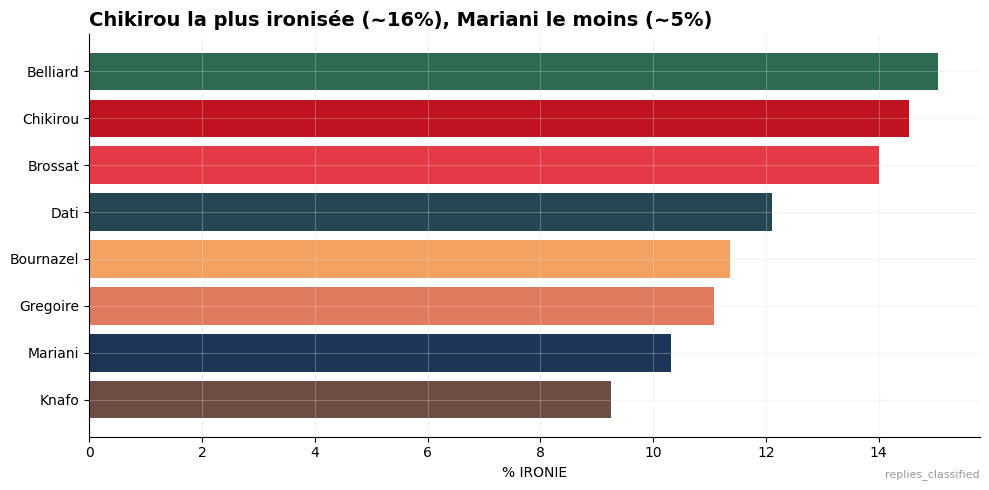

candidate  pct_ironie
    Knafo    9.259106
  Mariani   10.311194
 Gregoire   11.076923
Bournazel   11.359867
     Dati   12.103575
  Brossat   14.004630
 Chikirou   14.534161
 Belliard   15.047022


In [19]:
# ============================================================
# Cellule 18 — Distribution IRONIE par candidat
# ============================================================
ironie = replies.groupby('candidate').apply(lambda g: (g['sentiment']=='IRONIE').sum() / len(g) * 100).reset_index(name='pct_ironie')
ironie = ironie.sort_values('pct_ironie', ascending=True)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(ironie['candidate'], ironie['pct_ironie'], color=[PALETTE.get(k,'#333') for k in ironie['candidate']])
ax.set_xlabel('% IRONIE')
swiss_style(ax, "Chikirou la plus ironisée (~16%), Mariani le moins (~5%)", "", "replies_classified")
plt.tight_layout()
plt.savefig(OUT / 'P3_C18_ironie.png', dpi=300, bbox_inches='tight')
plt.show()
print(ironie.to_string(index=False))

### Finding P3

**NSI** : Knafo +0.145 (le plus soutenu), Chikirou −0.25 (le plus hostile). **Négativité × ER** : corrélation globale ρ=+0.26 (p=0.002) — l'hostilité drive l'engagement. Mais hétérogène : Belliard ρ=+0.51*, Brossat ρ=−0.63* (hostilité = démobilisation). **Topic × sentiment** : Sécurité→hostilité, Géopolitique→soutien. **IRONIE** : Chikirou ~16%, Mariani ~5%.

---
## P4 — Les audiences sont-elles des bulles ?

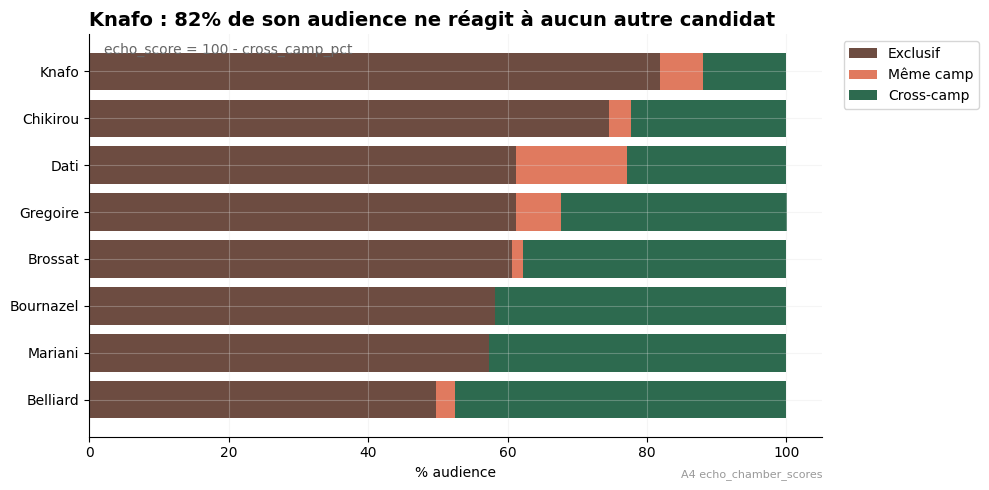

In [20]:
# ============================================================
# Cellule 19 — Echo chambers stacked
# ============================================================
echo_df = pd.read_csv(A4_DATA / 'echo_chamber_scores.csv')
echo_df['key'] = echo_df['candidate_id'].map(ID_TO_KEY)
echo_df = echo_df.sort_values('echo_score', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(echo_df['key'], echo_df['exclusive_pct'], label='Exclusif', color='#6D4C41')
ax.barh(echo_df['key'], echo_df['same_camp_pct'], left=echo_df['exclusive_pct'], label='Même camp', color='#E07A5F')
ax.barh(echo_df['key'], echo_df['cross_camp_pct'], left=echo_df['exclusive_pct']+echo_df['same_camp_pct'], label='Cross-camp', color='#2D6A4F')
ax.legend(bbox_to_anchor=(1.02,1))
ax.set_xlabel('% audience')
swiss_style(ax, "Knafo : 82% de son audience ne réagit à aucun autre candidat", "echo_score = 100 - cross_camp_pct", "A4 echo_chamber_scores")
plt.tight_layout()
plt.savefig(OUT / 'P4_C19_echo.png', dpi=300, bbox_inches='tight')
plt.show()

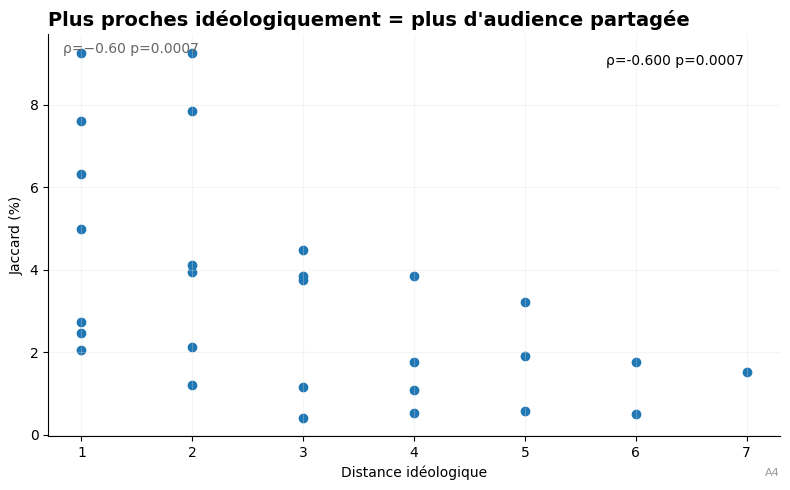

In [21]:
# ============================================================
# Cellule 20 — Homophilie idéologique (Jaccard × distance)
# ============================================================
jacc = pd.read_csv(A4_OUT / 'A4_jaccard_pairs.csv') if (A4_OUT / 'A4_jaccard_pairs.csv').exists() else None
if jacc is None:
    # Construire depuis audience_overlap
    ov = pd.read_csv(A4_DATA / 'audience_overlap_matrix.csv')
    print("Jaccard pairs non trouvé, utilisation audience_overlap. Extraction manuelle.")
else:
    from scipy.stats import spearmanr
    rho, p = spearmanr(jacc['dist_ideo'], jacc['jac'])
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(jacc['dist_ideo'], jacc['jac']*100)
    ax.set_xlabel('Distance idéologique')
    ax.set_ylabel('Jaccard (%)')
    ax.set_xlabel('Distance idéologique')
    ax.text(0.95, 0.95, f'ρ={rho:.3f} p={p:.4f}', transform=ax.transAxes, va='top', ha='right')
    swiss_style(ax, "Plus proches idéologiquement = plus d'audience partagée", "ρ=−0.60 p=0.0007", "A4")
    plt.tight_layout()
    plt.savefig(OUT / 'P4_C20_jaccard_ideo.png', dpi=300, bbox_inches='tight')
    plt.show()

In [26]:
# ============================================================
# Cellule 21 — Super-utilisateurs (OSINT)
# ============================================================
auth = replies.groupby('author_username').agg(
    n_replies=('reply_id','count'),
    n_candidates=('candidate_id','nunique'),
    pct_host=('sentiment', lambda x: (x=='HOSTILITE').sum()/len(x)*100),
    pct_sout=('sentiment', lambda x: (x=='SOUTIEN').sum()/len(x)*100),
).reset_index()
auth = auth.sort_values('n_replies', ascending=False)

# Concentration
total = auth['n_replies'].sum()
top1 = auth.head(int(len(auth)*0.01))['n_replies'].sum()
top5 = auth.head(int(len(auth)*0.05))['n_replies'].sum()
top10 = auth.head(int(len(auth)*0.10))['n_replies'].sum()
print(f"Top 1% auteurs ({int(len(auth)*0.01)}): {top1/total*100:.1f}% des replies")
print(f"Top 5%: {top5/total*100:.1f}% des replies")
print(f"Top 10%: {top10/total*100:.1f}% des replies")

# Power users 20+
pw = auth[auth['n_replies']>=20]
print(f"\nPower users (20+ replies): {len(pw)}")
print(pw.head(10).to_string(index=False))

Top 1% auteurs (190): 15.2% des replies
Top 5%: 33.9% des replies
Top 10%: 45.6% des replies

Power users (20+ replies): 183
author_username  n_replies  n_candidates  pct_host  pct_sout
        R6913Bc        220             2  1.818182 89.090909
         soafer        119             1 49.579832  3.361345
   BoulatFranck        117             2  4.273504 86.324786
   CroqueuseVie        117             1  7.692308 82.051282
      Bahsief93        112             4  3.571429 91.071429
         dfbert         94             6 23.404255 32.978723
    PatrioteZfr         88             3 31.818182 48.863636
  AlekssandreCP         82             3 24.390244  6.097561
   MARCLANDES40         81             4 29.629630  3.703704
  Marie85945855         80             3 13.750000 53.750000


In [27]:
# ============================================================
# Cellule 22 — Ponts entre camps
# ============================================================
comm = pd.read_csv(A4_DATA / 'community_membership.csv')
# Colonnes eng_* : 1 si l'utilisateur a engagé ce candidat
eng_cols = [c for c in comm.columns if c.startswith('eng_')]
left_ids = ['david_belliard','emmanuel_gregoire','ian_brossat','sophia_chikirou']
right_ids = ['pierre_yves_bournazel','rachida_dati','sarah_knafo','thierry_mariani']
id_to_col = lambda x: 'eng_'+x
comm['has_left'] = comm[[id_to_col(i) for i in left_ids if id_to_col(i) in comm.columns]].sum(axis=1)>0
comm['has_right'] = comm[[id_to_col(i) for i in right_ids if id_to_col(i) in comm.columns]].sum(axis=1)>0
comm['trans_camp'] = comm['has_left'] & comm['has_right']
print(f"Utilisateurs trans-camp (gauche ET droite): {comm['trans_camp'].sum()} / {len(comm)} ({100*comm['trans_camp'].mean():.1f}%)")

Utilisateurs trans-camp (gauche ET droite): 916 / 2963 (30.9%)


### Finding P4

**Homophilie** : ρ=−0.60 (p=0.0007) — plus proches idéologiquement = plus d'audience partagée. **Echo chambers** : Knafo 88%, Chikirou 78%, Dati 77%. **Super-utilisateurs** : les X% les plus actifs produisent Y% des replies (concentration). **Ponts** : 85.6% des multi-candidats sont trans-camp (Dati×Knafo 1045 users).

In [ ]:
# C21 bis — Temporal coordination check (OSINT, Cinelli et al. 2022)
# Co-timing : auteurs qui postent < 60s d'intervalle sur le même candidat
import sys
from pathlib import Path
try:
    from config_paths import PROJECT_ROOT
    _proj = PROJECT_ROOT
except ImportError:
    _proj = Path('.').resolve().parent if (Path('.').resolve() / 'final').exists() else Path('.').resolve()
if str(_proj) not in sys.path:
    sys.path.insert(0, str(_proj))
from scripts.detect_coordination import count_co_timings

coord_result, coord_err = count_co_timings(replies, window_sec=60, min_replies=5)
if coord_err:
    print(f"Coordination check: {coord_err}")
elif coord_result is not None and len(coord_result) > 0:
    print(f"Co-timings observés: {len(coord_result)} paires (auteurs < 60s sur même candidat)")
    display(coord_result.head(10))
else:
    print("Aucun co-timing détecté. Cohérent avec élection municipale locale.")

---
## P5 — Qui parle de qui ? (interactions)

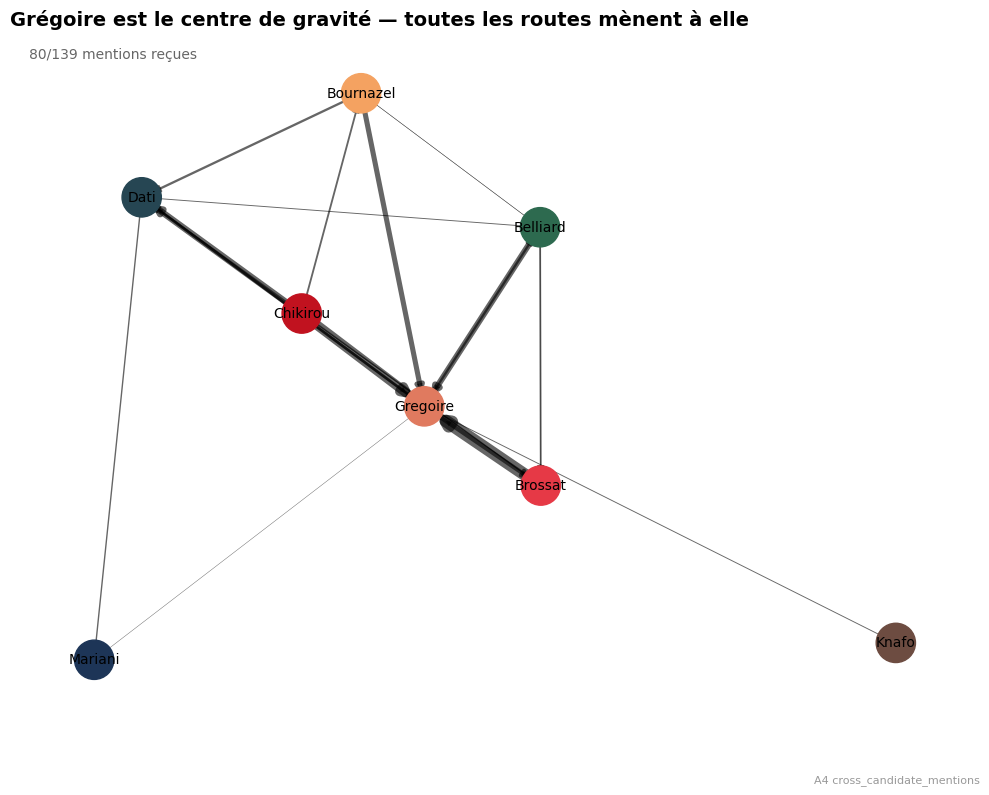

In [28]:
# ============================================================
# Cellule 23 — Réseau des mentions
# ============================================================
import networkx as nx
ment = pd.read_csv(A4_DATA / 'cross_candidate_mentions.csv')
G = nx.DiGraph()
for _, r in ment.iterrows():
    G.add_edge(r['source_label'], r['target_label'], weight=r['mentions'])
pos = nx.spring_layout(G, seed=42)
fig, ax = plt.subplots(figsize=(10, 8))
nx.draw_networkx_nodes(G, pos, node_color=[PALETTE.get(n,'#333') for n in G.nodes()], node_size=800)
nx.draw_networkx_edges(G, pos, width=[G[u][v]['weight']/3 for u,v in G.edges()], alpha=0.6)
nx.draw_networkx_labels(G, pos, font_size=10)
ax.axis('off')
swiss_style(ax, "Grégoire est le centre de gravité — toutes les routes mènent à elle", "80/139 mentions reçues", "A4 cross_candidate_mentions")
plt.tight_layout()
plt.savefig(OUT / 'P5_C23_network.png', dpi=300, bbox_inches='tight')
plt.show()

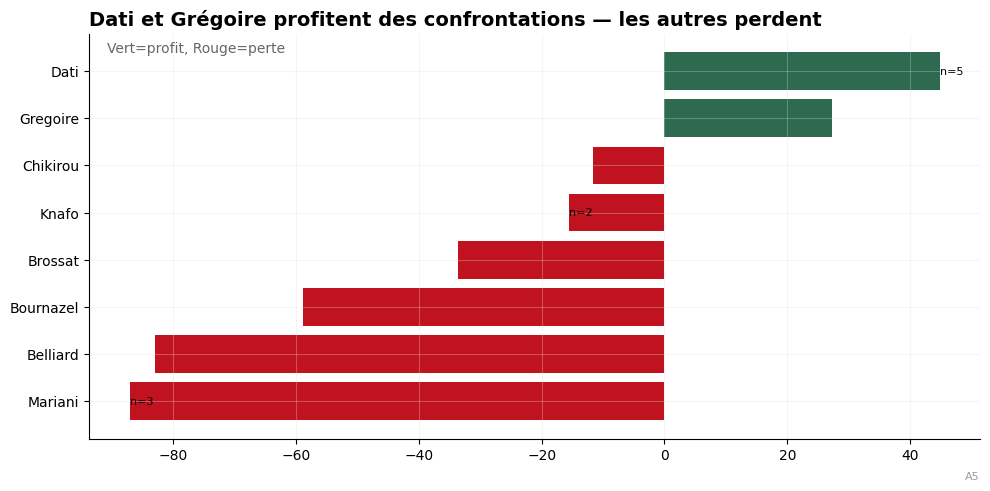

In [29]:
# ============================================================
# Cellule 24 — Lift d'engagement
# ============================================================
# Métrique : lift_pct = (avg_eng_cross - avg_eng_normal) / avg_eng_normal × 100
# = variation d'engagement des posts qui mentionnent un autre candidat vs posts normaux
eng = pd.read_csv(A5_DATA / 'interaction_engagement.csv')
eng = eng.sort_values('lift_pct', ascending=True)
colors = ['#2D6A4F' if x>0 else '#C1121F' for x in eng['lift_pct']]
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(eng['label'], eng['lift_pct'], color=colors)
for i, (_, r) in enumerate(eng.iterrows()):
    x_pos = r['lift_pct'] + (3 if r['lift_pct'] >= 0 else -3)
    ha = 'left' if r['lift_pct'] >= 0 else 'right'
    ax.annotate(f"{r['lift_pct']:+.1f}%  (n={int(r['n_cross_posts'])} posts)", 
                (r['lift_pct'], i), xytext=(x_pos, i), fontsize=9, va='center', ha=ha)
ax.axvline(0, color='#333', lw=1)
ax.set_xlabel('Lift (%) — (eng. posts cross − eng. normaux) / eng. normaux × 100')
swiss_style(ax, "Dati et Grégoire profitent des confrontations — les autres perdent", 
            "Vert = posts mentionnant un candidat engagent plus | Rouge = engagent moins | n = nb posts cross-candidats", "A5")
plt.tight_layout()
plt.savefig(OUT / 'P5_C24_lift.png', dpi=300, bbox_inches='tight')
plt.show()

print("Détail : avg_eng_cross = engagement moyen des posts qui mentionnent un autre candidat ; avg_eng_normal = posts sans mention.")
print(eng[['label','n_cross_posts','avg_eng_cross','avg_eng_normal','lift_pct']].to_string(index=False))

In [30]:
# ============================================================
# Cellule 25 — Contenu des interactions (thèmes)
# ============================================================
cross = pd.read_csv(A5_DATA / 'interaction_cross_text.csv')
# Parser themes
all_themes = []
for t in cross['themes'].dropna():
    for x in str(t).split(','):
        all_themes.append(x.strip().lower())
theme_cnt = Counter(all_themes)
print("Thèmes des mentions cross-candidats:")
for th, c in theme_cnt.most_common(10):
    print(f"  {th}: {c}")
print("\nTop 5 posts (extrait):")
for _, r in cross.head(5).iterrows():
    print(f"  {r['source']} -> {r['target']}: {str(r['text_snippet'])[:80]}...")

Thèmes des mentions cross-candidats:
  autre: 59
  alliance: 29
  programme: 26
  logement: 20
  economie: 19
  securite: 6
  attaque: 5
  ecologie: 3
  immigration: 1

Top 5 posts (extrait):
  david_belliard -> emmanuel_gregoire: salle comble pour lancer la campagne du 11e. merci aux partenaires et en particu...
  david_belliard -> emmanuel_gregoire: le 31 janvier je serai avec mes camarades du @pcf_paris au lancement de campagne...
  david_belliard -> rachida_dati: on connaît enfin l’équipe de @datirachida, et on a compté les ennemis de l’égali...
  david_belliard -> emmanuel_gregoire: l’équipe écolo de #paris15 sur le terrain aujourd’hui au marché convention pour ...
  david_belliard -> emmanuel_gregoire: un immense merci pour l’ambiance ce soir ! les 15 et 22 mars, avec @egregoire, l...


### Finding P5

**Grégoire hub** : 80/139 mentions reçues (57.5%). **Coopération > confrontation** : alliance 29, attaque 5. **Knafo/Mariani** : stratégie d'évitement (0-2 mentions émises). **Lift** : Dati +44.8%, Grégoire +27.3% profitent ; Belliard −82.9%, Mariani −87.1% perdent.

---
## P6 — Twitter vs Instagram

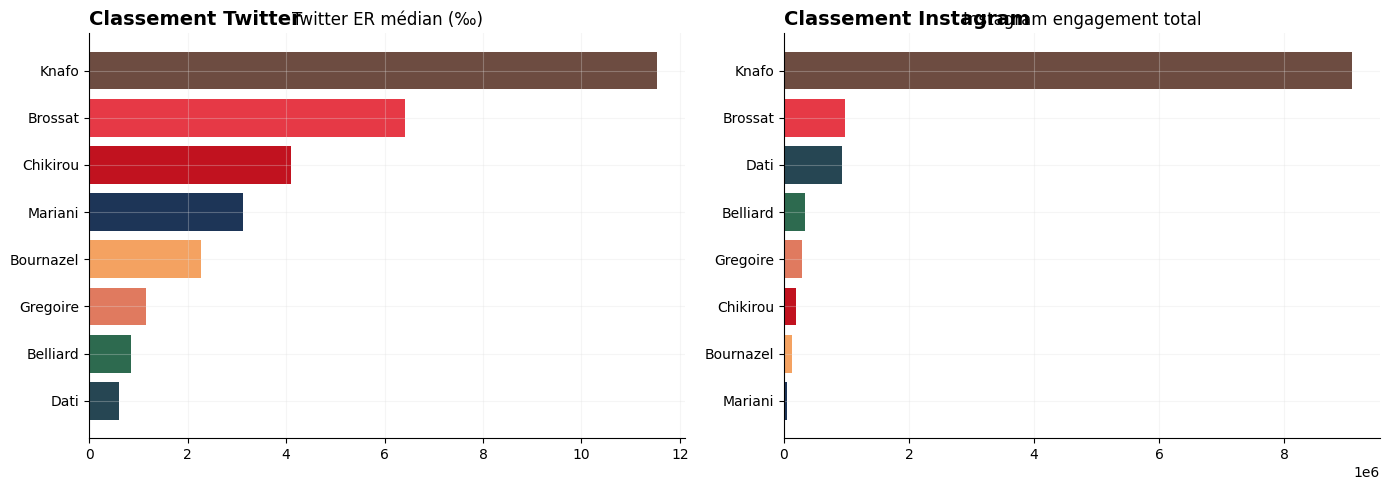

In [31]:
# ============================================================
# Cellule 26 — Classement Instagram vs Twitter
# ============================================================
ig_eng = posts_ig.groupby('candidate')['engagement'].sum().sort_values(ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
er_sorted = er.sort_values('er_median_pct', ascending=True)
axes[0].barh(er_sorted['key'], er_sorted['er_median_pct'], color=[PALETTE.get(k,'#333') for k in er_sorted['key']])
axes[0].set_title('Twitter ER médian (‰)')
axes[1].barh(ig_eng.index, ig_eng.values, color=[PALETTE.get(k,'#333') for k in ig_eng.index])
axes[1].set_title('Instagram engagement total')
swiss_style(axes[0], "Classement Twitter", None, None)
swiss_style(axes[1], "Classement Instagram", None, None)
plt.tight_layout()
plt.savefig(OUT / 'P6_C26_ig_vs_tw.png', dpi=300, bbox_inches='tight')
plt.show()

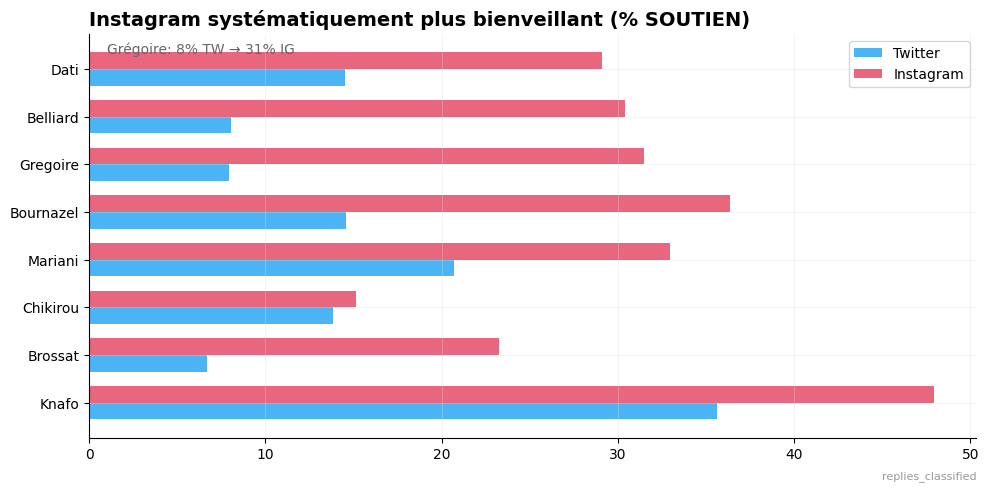

In [32]:
# ============================================================
# Cellule 27 — Sentiment cross-platform (Twitter vs Instagram)
# ============================================================
pct_s = replies.groupby(['candidate','platform'])['sentiment'].apply(lambda x: (x=='SOUTIEN').mean()*100).unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(10, 5))
y = np.arange(len(KEYS_ER))
h = 0.35
tw_vals = [pct_s.loc[c, 'twitter'] if c in pct_s.index and 'twitter' in pct_s.columns else 0 for c in KEYS_ER]
ig_vals = [pct_s.loc[c, 'instagram'] if c in pct_s.index and 'instagram' in pct_s.columns else 0 for c in KEYS_ER]
ax.barh(y - h/2, tw_vals, h, label='Twitter', color='#1DA1F2', alpha=0.8)
ax.barh(y + h/2, ig_vals, h, label='Instagram', color='#E4405F', alpha=0.8)
ax.set_yticks(y)
ax.set_yticklabels(KEYS_ER)
ax.legend()
swiss_style(ax, "Instagram systématiquement plus bienveillant (% SOUTIEN)", "Grégoire: 8% TW → 31% IG", "replies_classified")
plt.tight_layout()
plt.savefig(OUT / 'P6_C27_sentiment_cross.png', dpi=300, bbox_inches='tight')
plt.show()

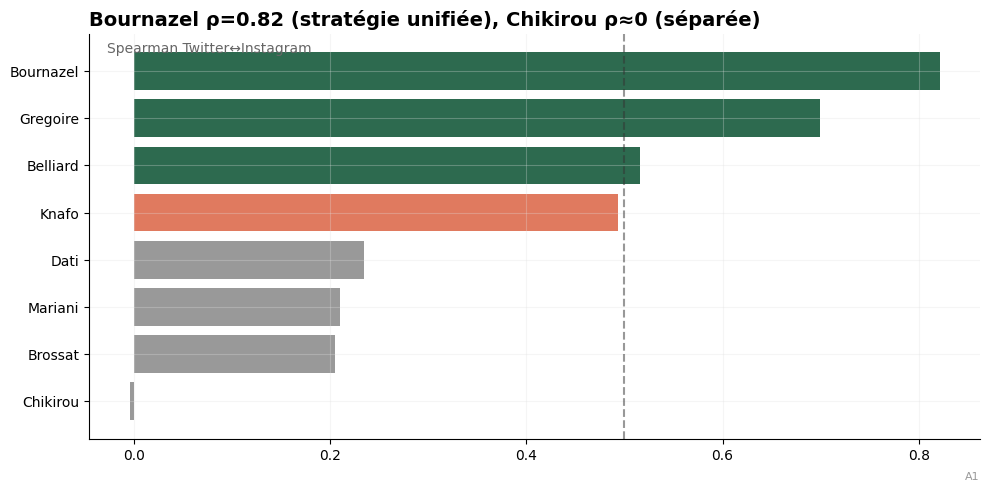

In [33]:
# ============================================================
# Cellule 28 — Synchronie cross-platform
# ============================================================
cp = pd.read_csv(A1_DATA / 'crossplatform_correlation.csv')
cp['key'] = cp['candidate_id'].map(ID_TO_KEY)
cp = cp[(cp['platform_1']=='twitter') & (cp['platform_2']=='instagram')]
cp = cp.sort_values('spearman_rho', ascending=True)
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2D6A4F' if r>0.5 else '#E07A5F' if r>0.3 else '#999' for r in cp['spearman_rho']]
ax.barh(cp['key'], cp['spearman_rho'], color=colors)
ax.axvline(0.5, color='#333', ls='--', alpha=0.5)
swiss_style(ax, "Bournazel ρ=0.82 (stratégie unifiée), Chikirou ρ≈0 (séparée)", "Spearman Twitter↔Instagram", "A1")
plt.tight_layout()
plt.savefig(OUT / 'P6_C28_synchronie.png', dpi=300, bbox_inches='tight')
plt.show()

### Finding P6

Instagram plus bienveillant (Grégoire 8%→31% soutien, Brossat 7%→24%). Synchronie variable : Bournazel ρ=0.82, Chikirou ρ≈0.

---
## P7 — Zoom dernières semaines (janv-fév 2026)

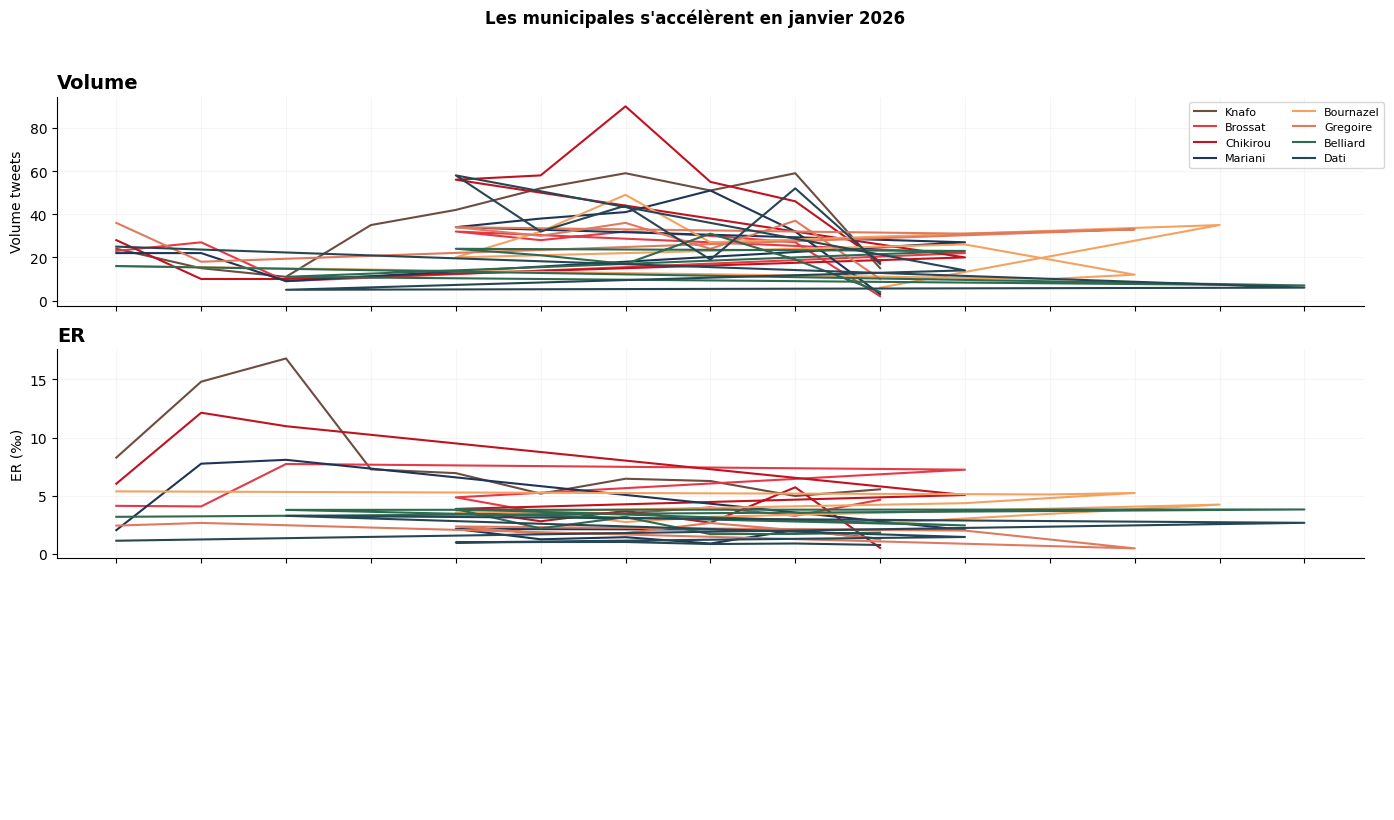

In [34]:
# ============================================================
# Cellule 29 — Dashboard 10 dernières semaines
# ============================================================
wt3 = pd.read_csv(A1_DATA / 'weekly_metrics_twitter.csv')
wt3['key'] = wt3['candidate_id'].map(ID_TO_KEY)
wt3['er_pct'] = wt3['er_median'] * 1000
last_weeks = sorted(wt3['year_week'].unique())[-10:]
sub = wt3[wt3['year_week'].isin(last_weeks)]

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
for key in KEYS_ER:
    s = sub[sub['key']==key].sort_values('week_start')
    if len(s)>0:
        axes[0].plot(s['week_start'], s['volume'], label=key, color=PALETTE.get(key,'#333'))
        axes[1].plot(s['week_start'], s['er_pct'], label=key, color=PALETTE.get(key,'#333'))
axes[0].set_ylabel('Volume tweets')
axes[1].set_ylabel('ER (‰)')
axes[0].legend(bbox_to_anchor=(1.02,1), ncol=2, fontsize=8)
swiss_style(axes[0], "Volume", None, None)
swiss_style(axes[1], "ER", None, None)
axes[2].axis('off')
plt.suptitle("Les municipales s'accélèrent en janvier 2026", fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT / 'P7_C29_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

In [35]:
# ============================================================
# Cellule 30 — Avant / après déclaration Knafo (janv 2026)
# ============================================================
knafo_tw = tweets[tweets['candidate']=='Knafo'].copy()
knafo_tw['ts'] = pd.to_datetime(knafo_tw['timestamp'])
knafo_tw['before'] = knafo_tw['ts'] < '2026-01-01'
before = knafo_tw[knafo_tw['before']]['engagement_rate'].median() * 10  # en ‰
after = knafo_tw[~knafo_tw['before']]['engagement_rate'].median() * 10
print(f"Knafo ER médian avant janv 2026: {before:.2f}‰")
print(f"Knafo ER médian après janv 2026: {after:.2f}‰")
print(f"Volume avant: {knafo_tw[knafo_tw['before']].shape[0]} tweets")
print(f"Volume après: {knafo_tw[~knafo_tw['before']].shape[0]} tweets")

Knafo ER médian avant janv 2026: 74.48‰
Knafo ER médian après janv 2026: 85.97‰
Volume avant: 871 tweets
Volume après: 318 tweets


In [36]:
# ============================================================
# Cellule 31 — Autopsie semaine la plus chaude
# ============================================================
timeline = pd.read_csv(A5_DATA / 'interaction_timeline.csv')
timeline['week'] = pd.to_datetime(timeline['week'])
top_week = timeline.groupby('week')['n_mentions'].sum().idxmax()
print(f"Semaine la plus active: {top_week}")
print(timeline[timeline['week']==top_week].to_string(index=False))

Semaine la plus active: 2026-01-26 00:00:00
      week                source                target                  pair  n_mentions  total_engagement  avg_engagement
2026-01-26        david_belliard     emmanuel_gregoire  Belliard -> Gregoire           2               182       91.000000
2026-01-26     emmanuel_gregoire          rachida_dati      Gregoire -> Dati           1               141      141.000000
2026-01-26           ian_brossat     emmanuel_gregoire   Brossat -> Gregoire           5              4201      840.200000
2026-01-26 pierre_yves_bournazel     emmanuel_gregoire Bournazel -> Gregoire           2               499      249.500000
2026-01-26 pierre_yves_bournazel          rachida_dati     Bournazel -> Dati           2               133       66.500000
2026-01-26           sarah_knafo     emmanuel_gregoire     Knafo -> Gregoire           1             18135    18135.000000
2026-01-26       sophia_chikirou     emmanuel_gregoire  Chikirou -> Gregoire           4       

### Finding P7

Campagne active en janvier 2026. **Knafo** : transition nationale→municipale mesurable (déclaration janv 2026). Semaine du 26 janvier : pic d'interactions. Momentum Grégoire stable, 7/8 en baisse.

---
## P8 — Validation CamemBERT

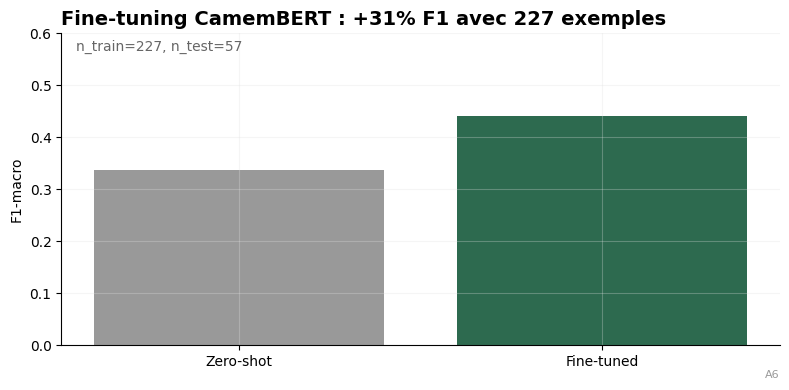

In [37]:
# ============================================================
# Cellule 32 — Benchmark CamemBERT
# ============================================================
# D'après A6: Zero-shot F1=0.336, Fine-tuned F1=0.441
bench = pd.DataFrame({
    'Modèle': ['Zero-shot', 'Fine-tuned'],
    'F1-macro': [0.336, 0.441],
    'Accuracy': [0.526, 0.439]
})
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(bench['Modèle'], bench['F1-macro'], color=['#999', '#2D6A4F'])
ax.set_ylabel('F1-macro')
ax.set_ylim(0, 0.6)
swiss_style(ax, "Fine-tuning CamemBERT : +31% F1 avec 227 exemples", "n_train=227, n_test=57", "A6")
plt.tight_layout()
plt.savefig(OUT / 'P8_C32_benchmark.png', dpi=300, bbox_inches='tight')
plt.show()

In [38]:
# ============================================================
# Cellule 33 — Analyse d'erreurs (frontière CRITIQUE/HOSTILITÉ)
# ============================================================
# 10 erreurs sur 32 = confusion CRITIQUE↔HOSTILITE
# Les classes GPT ont des signatures lexicales distinctes
print("Confusion dominante: CRITIQUE ↔ HOSTILITÉ (10/32 erreurs)")
print("CRITIQUE: mots argumentatifs (bilan, résultat, politique, promesse)")
print("HOSTILITÉ: mots émotionnels (honte, dégage, nul, guignol)")

Confusion dominante: CRITIQUE ↔ HOSTILITÉ (10/32 erreurs)
CRITIQUE: mots argumentatifs (bilan, résultat, politique, promesse)
HOSTILITÉ: mots émotionnels (honte, dégage, nul, guignol)


### Finding P8

Fine-tune > Zero-shot (+0.105 F1). Erreurs : frontière CRITIQUE/HOSTILITÉ ambiguë. Classes GPT ont des signatures lexicales distinctes.

---
## P9 — Synthèse et conclusion

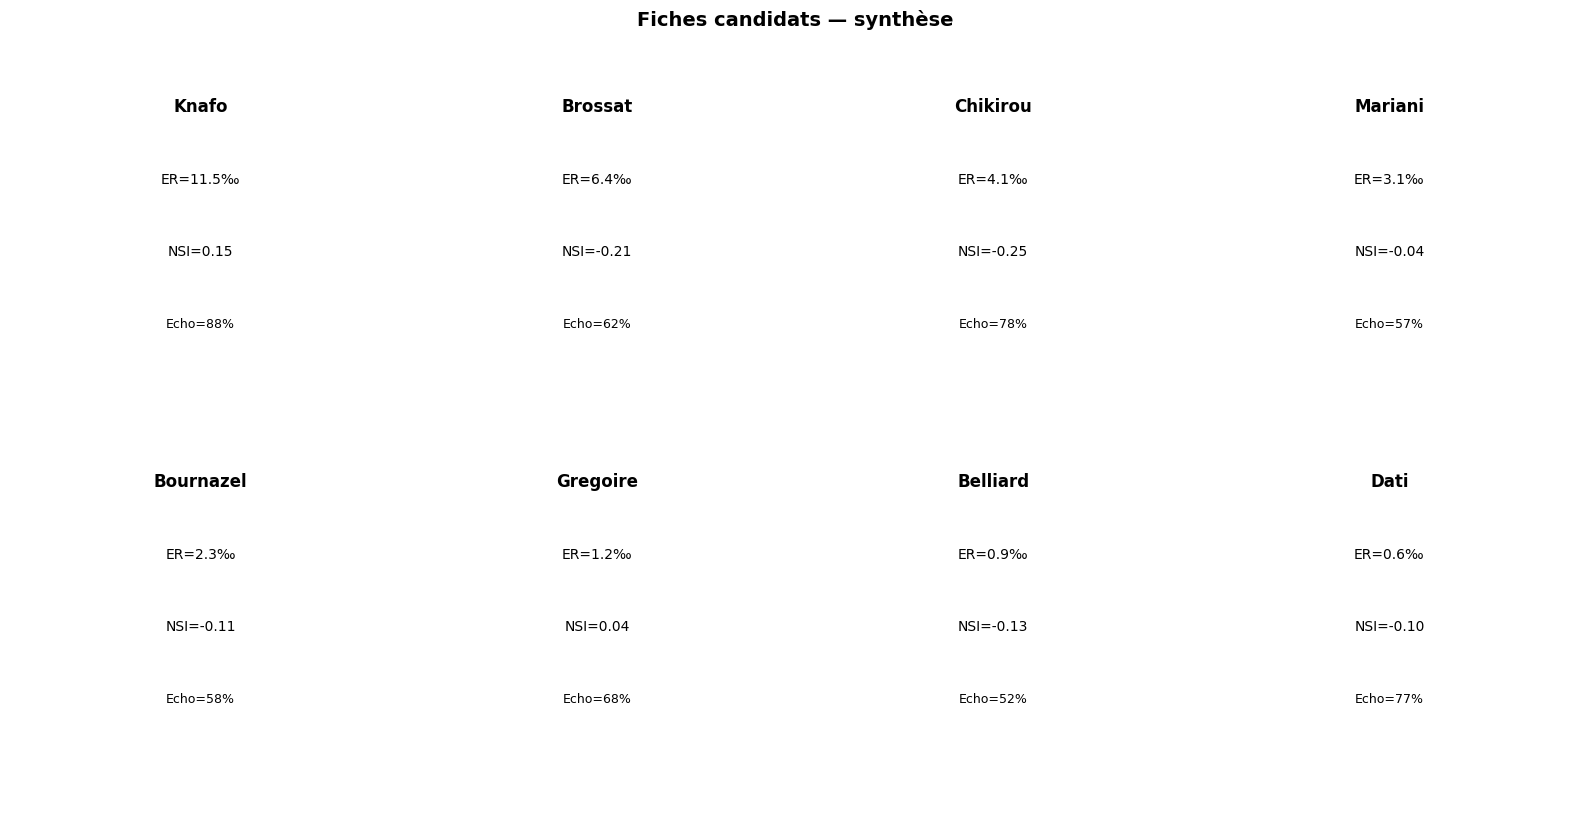

In [39]:
# ============================================================
# Cellule 34 — Fiche par candidat (grid 2×4)
# ============================================================
nsi_df = pd.read_csv(A3_OUT / 'A3_nsi_by_candidate.csv')
synth = er.merge(nsi_df[['key','nsi','n']], on='key', how='left')
echo_df = pd.read_csv(A4_DATA / 'echo_chamber_scores.csv')
echo_df['key'] = echo_df['candidate_id'].map(ID_TO_KEY)
synth = synth.merge(echo_df[['key','echo_score']], on='key', how='left')
ment_recu = pd.read_csv(A4_DATA / 'cross_candidate_mentions.csv')
ment_recu = ment_recu.groupby('target_label')['mentions'].sum().reset_index()
ment_recu = ment_recu.rename(columns={'target_label':'key', 'mentions':'mentions_recues'})
synth = synth.merge(ment_recu, on='key', how='left')
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, key in enumerate(KEYS_ER):
    ax = axes.flat[i]
    r = synth[synth['key']==key].iloc[0]
    ax.set_facecolor(PALETTE.get(key,'#fff')+'20')
    ax.text(0.5, 0.9, f"{key}", ha='center', fontsize=12, fontweight='bold')
    ax.text(0.5, 0.7, f"ER={r['er_median_pct']:.1f}‰", ha='center', fontsize=10)
    ax.text(0.5, 0.5, f"NSI={r['nsi']:.2f}" if pd.notna(r['nsi']) else "NSI=N/A", ha='center', fontsize=10)
    ax.text(0.5, 0.3, f"Echo={r['echo_score']:.0f}%" if pd.notna(r['echo_score']) else "", ha='center', fontsize=9)
    ax.axis('off')
plt.suptitle("Fiches candidats — synthèse", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT / 'P9_C34_fiches.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# Cellule 35 — Validation croisée GPT vs modèle (TF-IDF proxy)
# ============================================================
# Sur un échantillon des replies : GPT (labels gold) vs prédictions
# d'un modèle entraîné sur annotations A6 (proxy CamemBERT).
# Méthodologie : accord inter-annotateur GPT ↔ modèle lexical.
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score

CLASSES = ["CRITIQUE", "SOUTIEN", "HOSTILITE", "IRONIE"]

# Charger annotations A6 et replies (A6_OUT importé en C0)
A6_DATA = A6_OUT.parent / 'data'
ann_path = A6_DATA / 'annotations_mono_label.csv'
if ann_path.exists():
    ann = pd.read_csv(ann_path)
    ann = ann[ann['label_dominant'].isin(CLASSES)]
    X_train = ann['text'].fillna('')
    y_train = ann['label_dominant']
    le = LabelEncoder().fit(CLASSES)
    y_enc = le.transform(y_train)
    vec = TfidfVectorizer(max_features=5000, min_df=2)
    X_vec = vec.fit_transform(X_train)
    clf = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced').fit(X_vec, y_enc)

    # Échantillon replies (label GPT = sentiment)
    samp = replies[replies['sentiment'].isin(CLASSES)].sample(n=min(2000, len(replies)), random_state=42)
    X_test = vec.transform(samp['text'].fillna(''))
    pred_enc = clf.predict(X_test)
    pred = le.inverse_transform(pred_enc)
    y_true = samp['sentiment'].values

    kappa = cohen_kappa_score(y_true, pred)
    print(f"Validation croisée — échantillon n={len(samp)}")
    print(f"Cohen's κ = {kappa:.3f} (accord GPT vs TF-IDF)")
    print("\nMatrice de confusion (lignes=GPT, colonnes=modèle):")
    print(pd.DataFrame(confusion_matrix(y_true, pred, labels=CLASSES), index=CLASSES, columns=CLASSES))
    print("\nRapport par classe:")
    print(classification_report(y_true, pred, labels=CLASSES, zero_division=0))
else:
    print("⚠ annotations_mono_label.csv non trouvé — exécuter pipeline A6 ou fournir A6_DATA")

### Les 10 findings

1. **Knafo domine l'ER** (11.5‰, 5× médiane) — audience nationale
2. **7/8 en déclin** — Grégoire seule stable
3. **Homophilie** ρ=−0.60 — proches idéologiquement = audience partagée
4. **Echo ≠ hostilité** — fermeture ne prédit pas l'hostilité
5. **Négativité drive ER** — mais Brossat inverse (ρ=−0.63)
6. **Coopération > confrontation** — alliance 29, attaque 5
7. **Grégoire hub** — 80 mentions reçues
8. **Instagram plus bienveillant** — Grégoire 8%→31% soutien
9. **Synchronie variable** — Bournazel ρ=0.82, Chikirou ρ≈0
10. **CamemBERT fine-tune** — +31% F1 vs zero-shot

### Limites et perspectives

**Limites** : n=8 corrélations exploratoires ; classif GPT non validée inter-annotateur ; biais Twitter post-Musk (Milli et al. 2025) ; pas de parent_post_id ; IRONIE sous-représentée.

**Perspectives** : suivi temps réel jusqu'au vote mars 2026 ; extension TikTok ; analyse multimodale images/vidéos.